In [2]:
import json
import logging
import joblib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from mofapy2.run.entry_point import entry_point
import umap


### PATHS

In [3]:
out_dir = Path("/Users/bgadmin/Downloads")

biosample_summary_path = out_dir / "biosample_summary.csv"
golden_set_path = "gold_standard_20260604_1206.parquet" 
cnv_path = "progenetix_cnv/GLOBAL_cnv_gene_panel.csv"
bridge_path = "cnv_id_bridge.csv"
gene_panel_path=out_dir /"gene_cnv_cancer_panel.tsv"


### Load the file that are needed :
    -biosample_summary.csv
    -golden_set (the file which havev all the sample that have RNAseq+Methylation+CNV)
    -gene_cnv_cancer_panel.tsv
    -cnv_id_bride (have the correspondance between analysis_id and biosample_id)
    -Global_cnb_gene_panel.csv (have the CNV coming fron the TCGA and cBioportal)

In [4]:
# 1. Biosample summary
biosample_cols = [
    "biosample_id", "individual_id", "analysis_id",
    "platform_id", "histological_diagnosis_id",
    "icdo_topography_id", "icdo_morphology_id",
    "pathological_stage_id", "sample_origin_type_id",
    "cohorts",
]
bios = pd.read_csv(biosample_summary_path, sep=",", usecols=biosample_cols, dtype=str)

# 2. Gene CNV cancer panel 

gene_panel = pd.read_csv(
    gene_panel_path,
    sep="\t",
    dtype={
        "analysis_id": str,
        "gene_symbol":  str,
        "gene_id":      str,
        "chrom":        str,
        "start":        int,
        "end":          int,
        "dup_frac":     float,
        "del_frac":     float,
        "hldup_frac":   float,
        "hldel_frac":   float,
    },
)
panel_ana_ids = gene_panel["analysis_id"].unique()
print(f"unique analyses in gene_panel : {len(panel_ana_ids):,}")

# 2. Golden set
golden_set = pd.read_parquet(golden_set_path)
golden_set["biosample_id"] = golden_set["biosample_id"].astype(str)

# 3. Bridge analysis_id → biosample_id
bridge = pd.read_csv(bridge_path, dtype=str)
golden_biosample_ids  = set(golden_set["biosample_id"])
golden_analysis_ids   = set(
    bridge.loc[bridge["biosample_id"].isin(golden_biosample_ids), "analysis_id"]
    .astype(str)
)
print(f"biosample_id in golden set           : {len(golden_biosample_ids):,}")
print(f"analysis_id correspondance (via bridge): {len(golden_analysis_ids):,}")

# 4. CNV 
my_cnv = pd.read_csv(cnv_path, sep=",", dtype={"biosample_id": str})
my_cnv_biosample_ids = set(my_cnv["biosample_id"].astype(str))

# 5. bios_golden — intersection on analysis_id 
bios_golden = bios[
    bios["analysis_id"].isin(golden_analysis_ids) # Include only samples present in the reference Golden Set
    & bios["biosample_id"].isin(my_cnv_biosample_ids) #Include only samples for which have CNV data
    #Exclude technical platforms considered unreliable or out-of-scope
    & (bios["platform_id"] != "EFO:0001456")
    & (bios["platform_id"] != "EFO:0002701")
].copy()

print(f"\nbios total                  : {bios.shape[0]:,}")
print(f"golden set (biosample_id)   : {len(golden_biosample_ids):,}")
print(f"golden set (analysis_id)    : {len(golden_analysis_ids):,}")
print(f"CNV (biosample_id)          : {len(my_cnv_biosample_ids):,}")
print(f"bios_golden (after filters) : {bios_golden.shape[0]:,}")

unique analyses in gene_panel : 239,276
biosample_id in golden set           : 9,592
analysis_id correspondance (via bridge): 19,277

bios total                  : 257,365
golden set (biosample_id)   : 9,592
golden set (analysis_id)    : 19,277
CNV (biosample_id)          : 35,916
bios_golden (after filters) : 9,592


### Verification of the cell lines in the golden set and creation of the file with the cell lines 

In [5]:
def assign_source_group(cohorts):
    if cohorts is None or (isinstance(cohorts, float) and pd.isna(cohorts)):
        return "Other"

    if isinstance(cohorts, str):
        labels = [cohorts]
    else:
        try:
            labels = list(cohorts)
        except TypeError:
            labels = [str(cohorts)]

    labels_upper = [str(x).upper() for x in labels]

    if any("PGX:COHORT-CELLLINES" in lab for lab in labels_upper):
        return "CellLine"
    if any("GENIE" in lab for lab in labels_upper):
        return "GENIE"
    if any("CBIOPORTAL" in lab for lab in labels_upper):
        return "cBioPortal"
    if any("TCGA" in lab for lab in labels_upper):
        return "TCGA"

    return "Other"

bios["source_group"] = bios["cohorts"].apply(assign_source_group)

print(
    "\nsource_group counts (fichier global bios):\n",
    bios.groupby("source_group")["analysis_id"]
    .nunique()
    .sort_values(ascending=False),
)

# Extraction of the cell lines in the global
global_cellline_mask = bios["source_group"] == "CellLine"
global_cellline_samples = bios[global_cellline_mask].copy()

print("\nGlobal Cell-line analyses extracted:", global_cellline_samples["analysis_id"].nunique())


#------ Verification of the golden set, check if there is no cell line in it 

# check if the bios_golden has also the source_group columnn 
if "source_group" not in bios_golden.columns:
    bios_golden["source_group"] = bios_golden["cohorts"].apply(assign_source_group)

cellline_mask_golden = bios_golden["source_group"] == "CellLine"
cellline_samples_golden = bios_golden[cellline_mask_golden].copy()

# Extract of the potential cell lines in the golden set 
bios_golden = bios_golden[~cellline_mask_golden].copy()

print("\nCell-line analyses removed from golden set:", cellline_samples_golden["biosample_id"].nunique())


#-----Save of all the cell lines (cell line fron the goldenset and the gene_cnv_cancer_panel)
cellline_path = out_dir / "cellline_analyses_global.tsv"
(
    global_cellline_samples[["biosample_id", "individual_id", "platform_id", "cohorts"]]
    .drop_duplicates(subset=["biosample_id"])
    .to_csv(cellline_path, sep="\t", index=False)
)
print("Global cell line list saved to:", cellline_path)

# Same file but with the CNV data from the gene panel  
cellline_analysis_ids = set(
    global_cellline_samples["analysis_id"].dropna().astype(str)
)

cellline_panel = gene_panel[
    gene_panel["analysis_id"].isin(cellline_analysis_ids)
].copy()

if not cellline_panel.empty:
    # Join the meatadat on the analysis_id
    cellline_panel_enriched = cellline_panel.merge(
        global_cellline_samples[[
            "analysis_id", "biosample_id", "individual_id",
            "platform_id", "histological_diagnosis_id",
            "icdo_topography_id", "icdo_morphology_id",
            "cohorts", "source_group",
        ]].drop_duplicates(subset=["analysis_id"]),
        on="analysis_id",
        how="left",
    )

    cellline_panel_path = out_dir / "cellline_analyses_global_with_cnv_panel.tsv"
    cellline_panel_enriched.to_csv(cellline_panel_path, sep="\t", index=False)

    print(f"Cell line CNV panel saved to : {cellline_panel_path}")
    print(f"  → {cellline_panel_enriched['analysis_id'].nunique():,} analyses")
    print(f"  → {cellline_panel_enriched['gene_symbol'].nunique():,} gènes uniques")
else:
    print("No data find for the cell lines.")

print(f"\n Golden set after cleaninf  nettoyage : {bios_golden.shape[0]:,} samples")


source_group counts (fichier global bios):
 source_group
Other         96730
GENIE         83729
cBioPortal    38771
TCGA          32383
CellLine       5752
Name: analysis_id, dtype: int64

Global Cell-line analyses extracted: 5752

Cell-line analyses removed from golden set: 0
Global cell line list saved to: /Users/bgadmin/Downloads/cellline_analyses_global.tsv
Cell line CNV panel saved to : /Users/bgadmin/Downloads/cellline_analyses_global_with_cnv_panel.tsv
  → 5,752 analyses
  → 1,301 gènes uniques

 Golden set after cleaninf  nettoyage : 9,592 samples


In [6]:
# Filter golden_set tomkeep only the sample which are in the bios_golden
clean_biosample_ids = set(bios_golden["biosample_id"].astype(str))

golden_clean = golden_set[
    golden_set["biosample_id"].isin(clean_biosample_ids)
].copy()

print(f"The final golden set has : {golden_clean.shape[0]} samples.")

The final golden set has : 9592 samples.


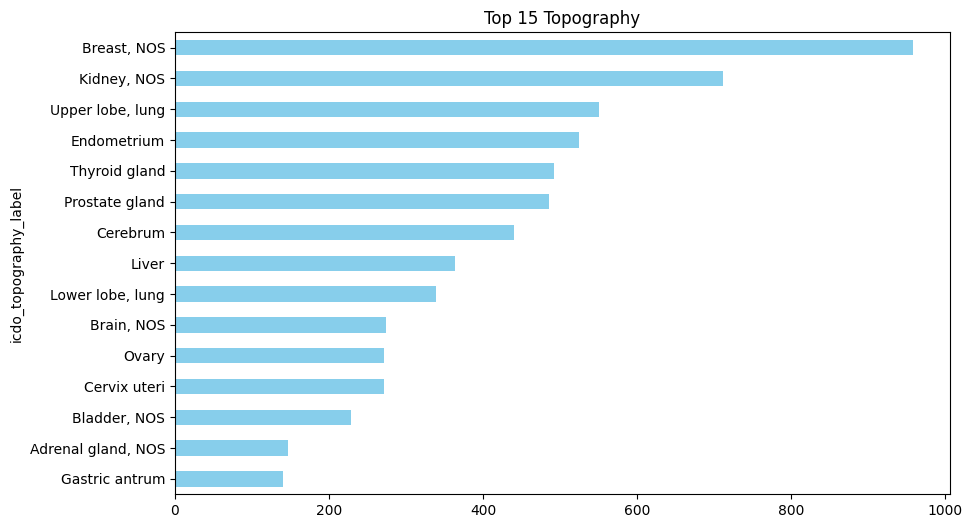

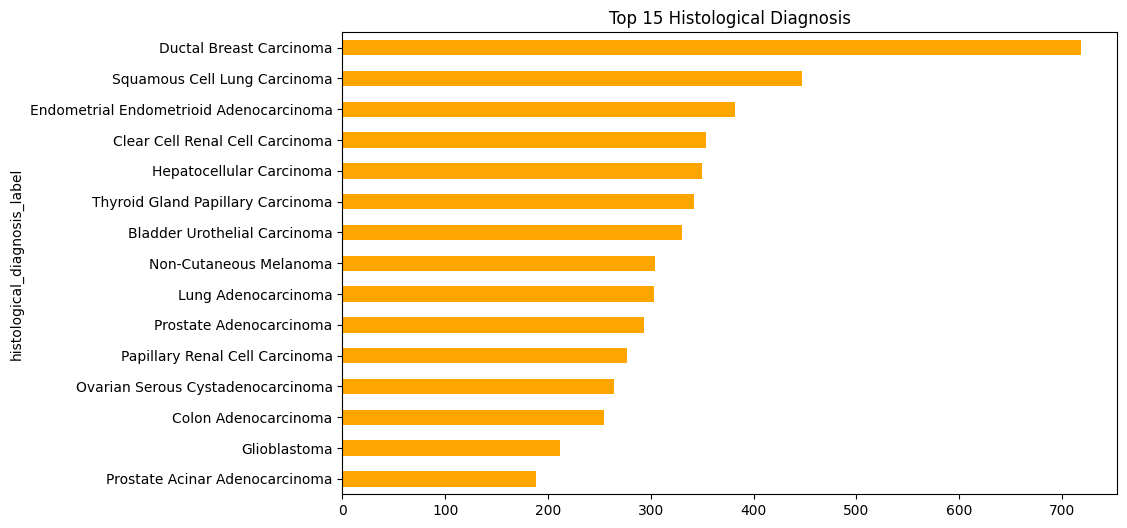

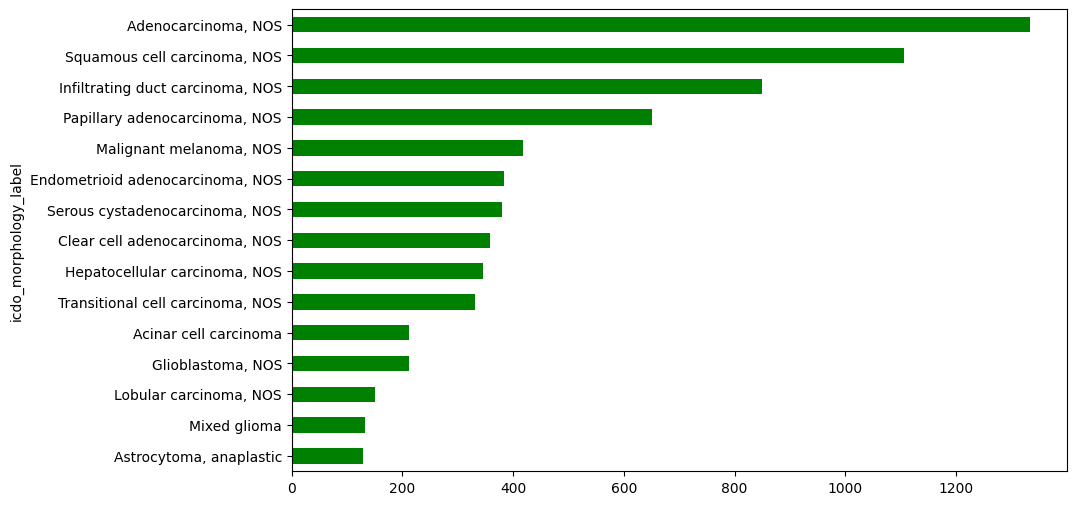

In [7]:
#Graphics
# Topography 
top_counts = golden_clean['icdo_topography_label'].value_counts().head(15)
plt.figure(figsize=(10, 6))
top_counts.plot(kind='barh', color='skyblue') 
plt.title('Top 15 Topography')
plt.gca().invert_yaxis()
plt.show()

# Histology
top_counts_histology = golden_clean['histological_diagnosis_label'].value_counts().head(15)
plt.figure(figsize=(10, 6))
top_counts_histology.plot(kind='barh', color='orange') 
plt.title('Top 15 Histological Diagnosis')
plt.gca().invert_yaxis()
plt.show()

# Morphology
top_counts_morphology = golden_clean['icdo_morphology_label'].value_counts().head(15)
plt.figure(figsize=(10, 6))
top_counts_morphology.plot(kind='barh', color='green') 
plt.gca().invert_yaxis()
plt.show()


### Divided the golden set in the different omic matrix :

In [8]:
cols_cnv       = [c for c in golden_clean.columns if c.startswith("cnv_")]
cols_rna_gdc   = [c for c in golden_clean.columns if c.startswith("rna_gdc_")]
cols_rna_cbio  = [c for c in golden_clean.columns if c.startswith("rna_cbio_")]
cols_meth_gdc  = [c for c in golden_clean.columns if c.startswith("meth_gdc_")]
cols_meth_cbio = [c for c in golden_clean.columns if c.startswith("meth_cbio_")]

print(f"CNV  colonnes : {len(cols_cnv)}")
print(f"RNA  colonnes : {len(cols_rna_gdc)} (GDC) + {len(cols_rna_cbio)} (cBio)")
print(f"Meth colonnes : {len(cols_meth_gdc)} (GDC) + {len(cols_meth_cbio)} (cBio)")

def merge_sources(df, cols_gdc, cols_cbio, omics_type: str = "rna"):
    """
    Merged GDC + cBio with priority for GDC.
    
    omics_type : "rna" ou "meth" ou "cnv"
    """
    genes_gdc  = {c.replace("rna_gdc_",  "")
                   .replace("meth_gdc_", "")
                   .replace("cnv_",      "") for c in cols_gdc}
    genes_cbio = {c.replace("rna_cbio_",  "")
                   .replace("meth_cbio_", "") for c in cols_cbio}
    all_genes  = genes_gdc | genes_cbio

    rows = {}
    for gene in all_genes:
        col_gdc  = next((c for c in cols_gdc  if c.endswith(f"_{gene}")), None)
        col_cbio = next((c for c in cols_cbio if c.endswith(f"_{gene}")), None)

        if col_gdc and col_cbio:
            gdc_series  = df[col_gdc].copy()
            cbio_series = df[col_cbio].copy()
            
            rows[gene] = gdc_series.combine_first(cbio_series)

        elif col_gdc:
            rows[gene] = df[col_gdc].copy()

        elif col_cbio:
            rows[gene] = df[col_cbio].copy()

    return pd.DataFrame(rows, index=df.index)
# Construction of the final cleaned matrix
X_rna = merge_sources(golden_clean, cols_rna_gdc, cols_rna_cbio)
X_meth = merge_sources(golden_clean, cols_meth_gdc, cols_meth_cbio)

# For the CNV, no merge 
X_cnv = golden_clean[cols_cnv].copy()
X_cnv.columns = [c.replace("cnv_", "") for c in X_cnv.columns]

print(f"Matrices prêtes :")
print(f"RNA (GDC+cBio) : {X_rna.shape}")
print(f"Meth (GDC+cBio): {X_meth.shape}")
print(f"CNV            : {X_cnv.shape}")

for name, mat in [("RNA", X_rna), ("Meth", X_meth)]:
    zero_frac = (mat == 0).mean().mean()
    nan_frac  = mat.isna().mean().mean()
    print(f"{name} : zero_frac={zero_frac:.3f}  nan_frac={nan_frac:.3f}")

# Vérifier TP53 spécifiquement
print("\nTP53 après correction :")
print(X_rna["TP53"].describe())
print(f"Zéros    : {(X_rna['TP53'] == 0).sum()}")
print(f"Non-NaN  : {X_rna['TP53'].notna().sum()}")

CNV  colonnes : 5204
RNA  colonnes : 1301 (GDC) + 1300 (cBio)
Meth colonnes : 1230 (GDC) + 1102 (cBio)
Matrices prêtes :
RNA (GDC+cBio) : (9592, 1303)
Meth (GDC+cBio): (9592, 1235)
CNV            : (9592, 5204)
RNA : zero_frac=0.034  nan_frac=0.002
Meth : zero_frac=0.001  nan_frac=0.063

TP53 après correction :
count    9592.000000
mean       46.723202
std        35.822362
min         0.872300
25%        22.895525
50%        39.040650
75%        61.354075
max       699.118167
Name: TP53, dtype: float64
Zéros    : 0
Non-NaN  : 9592


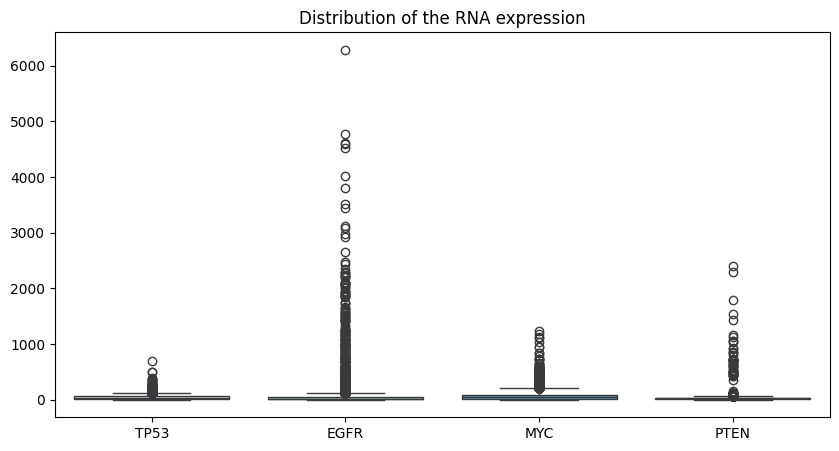

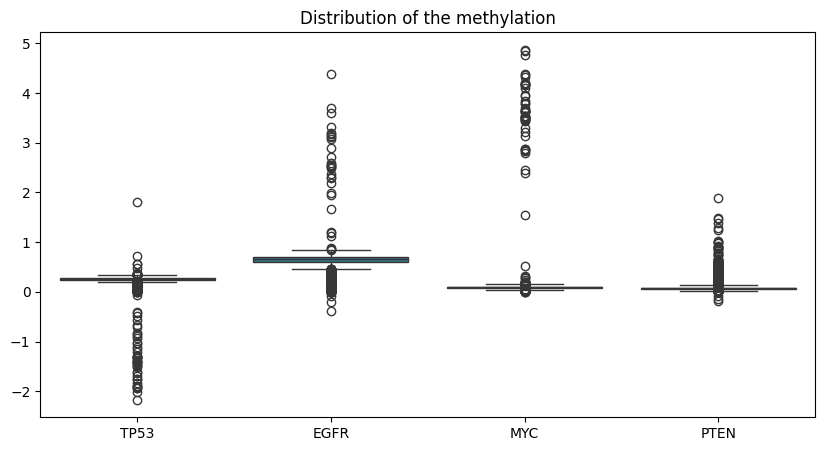

None of the selected genes are present in the CNV matrix.


In [9]:
# --- Graphiqs for the 3 omics---
genes_to_plot = ['TP53', 'EGFR', 'MYC', 'PTEN']

# 1. RNA
existing_rna = [g for g in genes_to_plot if g in X_rna.columns]
if existing_rna:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=X_rna[existing_rna], palette="Blues")
    plt.title("Distribution of the RNA expression")
    plt.show()

# 2. Méthylation
existing_meth = [g for g in genes_to_plot if g in X_meth.columns]
if existing_meth:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=X_meth[existing_meth], palette="viridis")
    plt.title("Distribution of the methylation")
    plt.show()

# 3. CNV
existing_cnv = [g for g in genes_to_plot if g in X_cnv.columns]
if existing_cnv:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=X_cnv[existing_cnv], palette="magma")
    plt.title("Distribution of CNV")
    plt.show()
else:
    print("None of the selected genes are present in the CNV matrix.")

In [10]:
# Diagnostic before continuing 
for name, mat in [("CNV", X_cnv), ("RNA", X_rna), ("Meth", X_meth)]:
    print(f"\n{'='*40}")
    print(f"{name} : {mat.shape[0]:,} samples × {mat.shape[1]:,} features")
    print(f"  NaN fraction      : {mat.isna().mean().mean():.3f}")
    print(f"  Colonnes 100% NaN : {mat.isna().all(axis=0).sum()}")
    print(f"  Lignes  100% NaN  : {mat.isna().all(axis=1).sum()}")
    print(f"  Min / Max         : {mat.min().min():.3f} / {mat.max().max():.3f}")


CNV : 9,592 samples × 5,204 features
  NaN fraction      : 0.000
  Colonnes 100% NaN : 0
  Lignes  100% NaN  : 0
  Min / Max         : 0.000 / 2.000

RNA : 9,592 samples × 1,303 features
  NaN fraction      : 0.002
  Colonnes 100% NaN : 2
  Lignes  100% NaN  : 0
  Min / Max         : -1.247 / 173270.062

Meth : 9,592 samples × 1,235 features
  NaN fraction      : 0.063
  Colonnes 100% NaN : 4
  Lignes  100% NaN  : 0
  Min / Max         : -4.217 / 6.668


### Supression of the NaN in the column and ligns

In [11]:
def clean_matrix(mat: pd.DataFrame, name: str, 
                 max_nan_col: float = 0.20,
                 max_nan_row: float = 0.30) -> pd.DataFrame:
    """
    Delete the patients ligns first ith too much NaN 
    Delete the genes columns with too much NaN 
    Delete  columns with zero variance
    """
    n0 = mat.shape

    # Filter the patient ligns 
    row_nan_frac = mat.isna().mean(axis=1)
    mat = mat.loc[row_nan_frac <= max_nan_row]
    print(f"[{name}] Patients (ligns) after NaN filter  ({max_nan_row:.0%}) : "
          f"{n0[0]:,} → {mat.shape[0]:,}")

    # Filter the genes columns 
    col_nan_frac = mat.isna().mean(axis=0)
    mat = mat.loc[:, col_nan_frac <= max_nan_col]
    print(f"[{name}] Genes (columns) after NaN filte ({max_nan_col:.0%})    : "
          f"{n0[1]:,} → {mat.shape[1]:,}")

    # Delete columns with zero variance 
    zero_var = mat.std(axis=0) == 0
    mat = mat.loc[:, ~zero_var]
    print(f"[{name}] Genes after the zero variance filter             : {mat.shape[1]:,}")
    print("-" * 60)

    return mat

X_cnv_clean  = clean_matrix(X_cnv,  "CNV",  max_nan_col=0.05, max_nan_row=0.10)
X_rna_clean  = clean_matrix(X_rna,  "RNA",  max_nan_col=0.20, max_nan_row=0.30)
X_meth_clean = clean_matrix(X_meth, "Meth", max_nan_col=0.20, max_nan_row=0.30)

[CNV] Patients (ligns) after NaN filter  (10%) : 9,592 → 9,592
[CNV] Genes (columns) after NaN filte (5%)    : 5,204 → 5,204
[CNV] Genes after the zero variance filter             : 5,128
------------------------------------------------------------
[RNA] Patients (ligns) after NaN filter  (30%) : 9,592 → 9,592
[RNA] Genes (columns) after NaN filte (20%)    : 1,303 → 1,301
[RNA] Genes after the zero variance filter             : 1,301
------------------------------------------------------------
[Meth] Patients (ligns) after NaN filter  (30%) : 9,592 → 9,592
[Meth] Genes (columns) after NaN filte (20%)    : 1,235 → 1,171
[Meth] Genes after the zero variance filter             : 1,171
------------------------------------------------------------


In [12]:
def impute_matrix(mat: pd.DataFrame, strategy: str = "median") -> pd.DataFrame:
    '''This function fills in the remaining missing data with the median value,
         making the matrix mathematically complete
        '''
    imp = SimpleImputer(strategy=strategy)
    arr = imp.fit_transform(mat)
    return pd.DataFrame(arr, index=mat.index, columns=mat.columns)

X_cnv_imp  = impute_matrix(X_cnv_clean,  strategy="median")
X_rna_imp  = impute_matrix(X_rna_clean,  strategy="median")
X_meth_imp = impute_matrix(X_meth_clean, strategy="median")

for name, original, imputed in [("CNV", X_cnv_clean, X_cnv_imp), 
                                 ("RNA", X_rna_clean, X_rna_imp), 
                                 ("Meth", X_meth_clean, X_meth_imp)]:
    nan_avant = original.isna().sum().sum()
    nan_apres = imputed.isna().sum().sum()
    print(f"[{name}] NaNs before : {nan_avant:,} | NaNs after : {nan_apres} | Forme : {imputed.shape}")

[CNV] NaNs before : 0 | NaNs after : 0 | Forme : (9592, 5128)
[RNA] NaNs before : 649 | NaNs after : 0 | Forme : (9592, 1301)
[Meth] NaNs before : 168,146 | NaNs after : 0 | Forme : (9592, 1171)


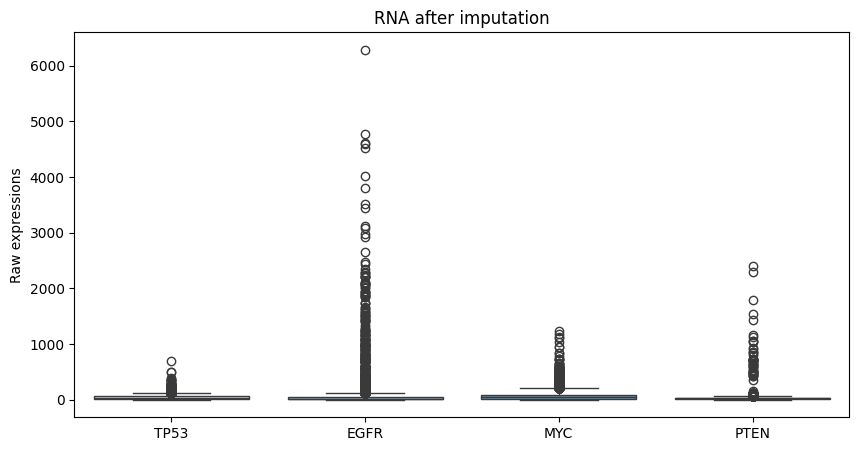

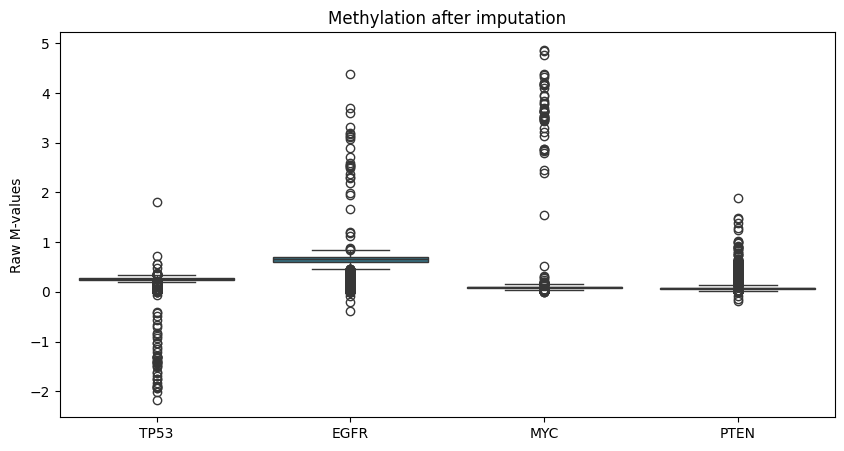

In [13]:
#Graph with gene example
genes_to_plot = ['TP53', 'EGFR', 'MYC', 'PTEN']

existing_rna_genes = [g for g in genes_to_plot if g in X_rna_imp.columns]

if existing_rna_genes:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=X_rna_imp[existing_rna_genes], palette="Blues")
    plt.title("RNA after imputation")
    plt.ylabel("Raw expressions")
    plt.show()
else:
    print("No examples genes in the matrix.")

existing_meth_genes = [g for g in genes_to_plot if g in X_meth_imp.columns]

if existing_meth_genes:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=X_meth_imp[existing_meth_genes], palette="viridis")
    plt.title("Methylation after imputation")
    plt.ylabel("Raw M-values")
    plt.show()
else:
    print("No examples genes in the matrix.")

In [14]:
#Dict for graph with "all" the samples
omics_dict_before = {
    "RNA": {
        "before": X_rna_imp,  
        "color_before": "crimson",
    },
    "Methylation": {
        "before": X_meth_imp,
        "color_before": "darkorange",
    },
    "CNV": {
        "before": X_cnv_imp, 
        "color_before": "purple", 
    }
}

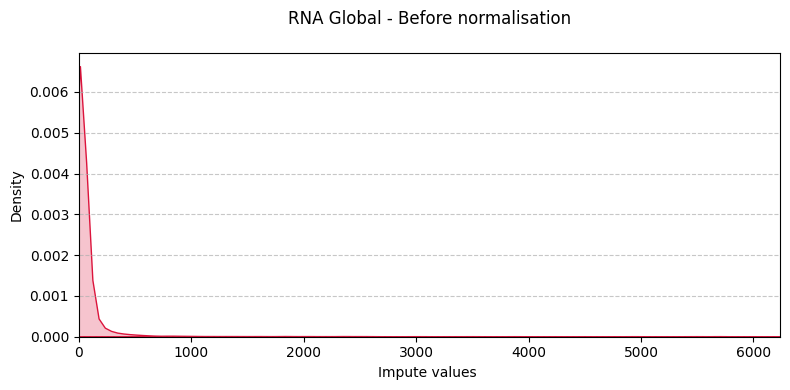

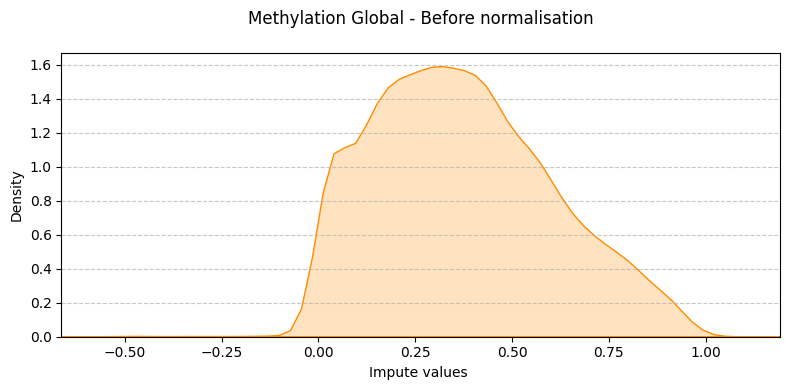

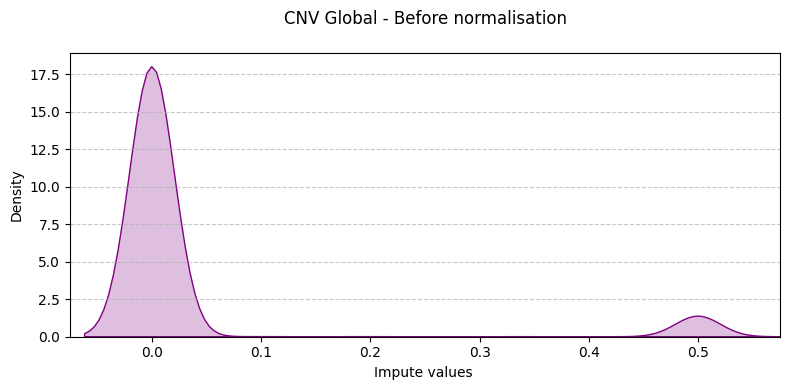

In [15]:
#Graphics before normalization with adaptated scale
n_samples = 10000

for omic_name, data in omics_dict_before.items():
    df_before = data["before"]
    
    flat_sample = df_before.values.ravel()
    sample_raw = np.random.choice(flat_sample, min(n_samples, len(flat_sample)), replace=False)
    
    p001 = np.nanpercentile(sample_raw, 0.1)
    p999 = np.nanpercentile(sample_raw, 99.9)
    
    margin = (p999 - p001) * 0.15
    xlim_min = p001 - margin
    xlim_max = p999 + margin
    
    if "RNA" in omic_name.upper() and xlim_min < 0:
        xlim_min = 0

    plt.figure(figsize=(8, 4))
    sns.kdeplot(sample_raw, fill=True, color=data["color_before"])
    
    # Application du nouveau cadre élargi
    plt.xlim(xlim_min, xlim_max)
    
    plt.title(f"{omic_name} Global - Before normalisation\n")
    plt.xlabel("Impute values ")
    plt.ylabel("Density")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Normlzsation

In [16]:
from sklearn.preprocessing import normalize, StandardScaler

# --- CNV : RobustScaler (distribution sparse avec outliers)
X_cnv_l2 = normalize(X_cnv_imp.values, norm='l2')

# StandardScaler pour centrer/réduire
scaler_cnv = StandardScaler()
X_cnv_norm = pd.DataFrame(
    scaler_cnv.fit_transform(X_cnv_l2),
    index=X_cnv_imp.index,
    columns=X_cnv_imp.columns
)

# --- RNA : log1p PUIS RobustScaler (double protection)
X_rna_log = np.log1p(X_rna_imp.clip(lower=0))  # clip évite log d'une valeur négative résiduelle
scaler_rna = RobustScaler()
X_rna_norm = pd.DataFrame(
    scaler_rna.fit_transform(X_rna_log),
    index=X_rna_imp.index,
    columns=X_rna_imp.columns
)


# --- Meth : QuantileTransformer (corrige l'asymétrie bimodale)
scaler_meth = QuantileTransformer(
    n_quantiles=1000,
    output_distribution="normal",
    random_state=0
)
X_meth_norm = pd.DataFrame(
    scaler_meth.fit_transform(X_meth_imp),
    index=X_meth_imp.index,
    columns=X_meth_imp.columns
)

In [17]:
omics_dict_after = {
    "RNA": {
        "after": X_rna_norm, 
        "color_after": "mediumseagreen"
    },
    "Methylation": { 
        "after": X_meth_norm, 
        "color_after": "royalblue"
    },
    #"CNV": { 
    #    "after": X_cnv_norm,
    #    "color_after": "orchid"
    #}
}

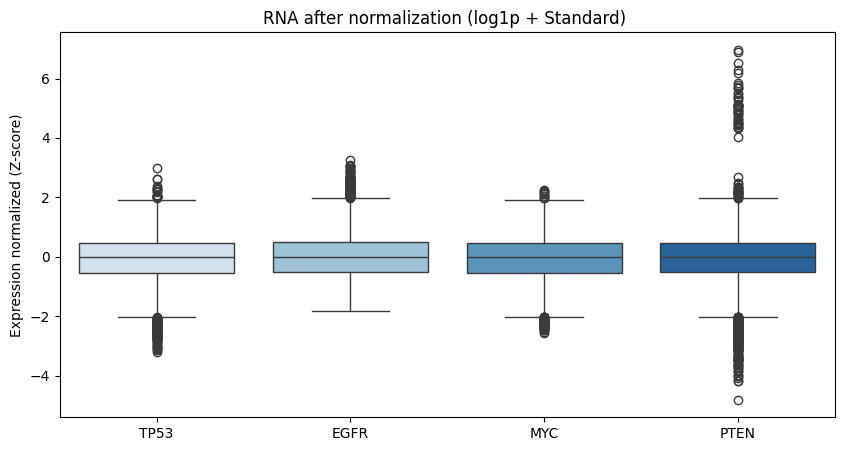

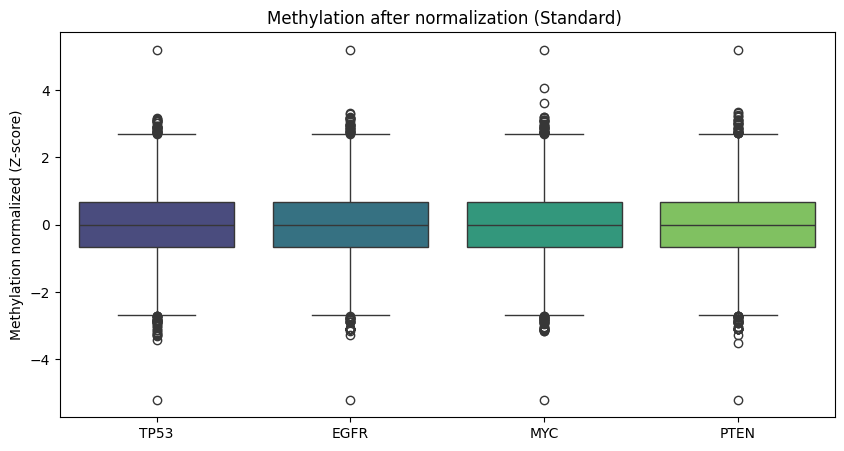

 No examples genes in the matrix


In [18]:
#Graphs with genes examples
genes_to_plot = ['TP53', 'EGFR', 'MYC', 'PTEN']

existing_rna_genes = [g for g in genes_to_plot if g in X_rna_norm.columns]
if existing_rna_genes:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=X_rna_norm[existing_rna_genes], palette="Blues")
    plt.title("RNA after normalization (log1p + Standard) ")
    plt.ylabel("Expression normalized (Z-score)")
    plt.show()

# Grph for the methylation after the normalization
existing_meth_genes = [g for g in genes_to_plot if g in X_meth_norm.columns]
if existing_meth_genes:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=X_meth_norm[existing_meth_genes], palette="viridis")
    plt.title("Methylation after normalization (Standard) ")
    plt.ylabel("Methylation normalized (Z-score)")
    plt.show()

# Graph for CNV after the normalization
existing_cnv_genes = [g for g in genes_to_plot if g in X_cnv_norm.columns]
if existing_cnv_genes:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=X_cnv_norm[existing_cnv_genes], palette="magma")
    plt.title("CNV after normalization (Standard)")
    plt.ylabel("CNV normalized (Z-score)")
    plt.show()
else:
    print(" No examples genes in the matrix")

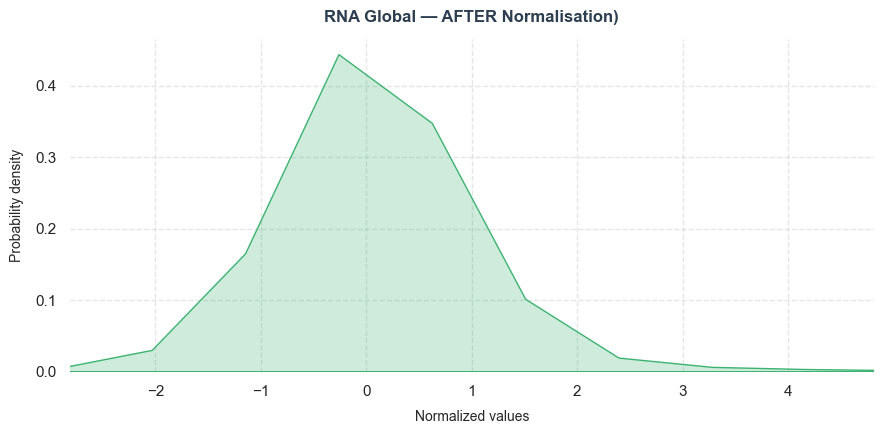

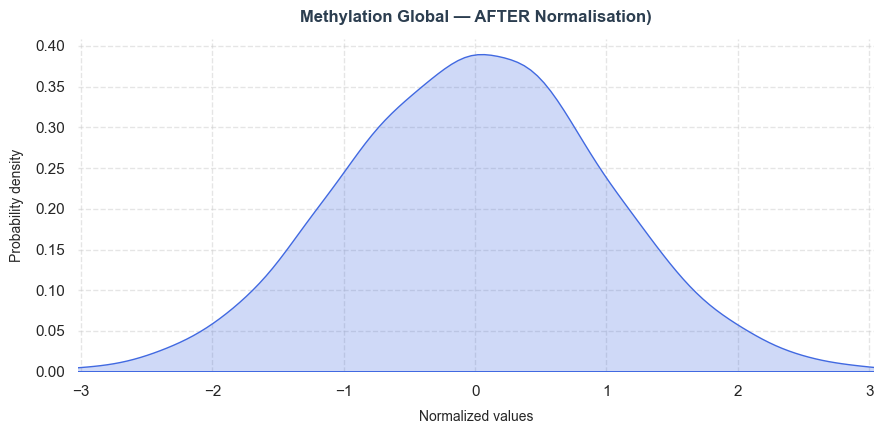

In [19]:
#Graphs after normalization

n_samples = 10000

for omic_name, data in omics_dict_after.items():
    df_after = data["after"]
    
    flat_sample = df_after.values.ravel()
    sample_norm = np.random.choice(flat_sample, min(n_samples, len(flat_sample)), replace=False)
    
    p01 = np.nanpercentile(sample_norm, 1)
    p99 = np.nanpercentile(sample_norm, 99)
    
    if abs(p99 - p01) < 1e-4:
        xlim_min, xlim_max = -0.5, 0.5
        title_range = "Focus autour de 0"
    else:
        margin = (p99 - p01) * 0.15 
        xlim_min = p01 - margin
        xlim_max = p99 + margin

    plt.figure(figsize=(9, 4.5), dpi=100)
    sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})
    
    sns.kdeplot(
        sample_norm, 
        fill=True, 
        color=data["color_after"], 
        alpha=0.25,           
        linewidth=1,          
        bw_adjust=1.2         
    )
    
    plt.xlim(xlim_min, xlim_max)
    
    plt.title(f"{omic_name} Global — AFTER Normalisation)", 
              fontsize=12, fontweight='bold', pad=12, color='#2c3e50')
    plt.xlabel("Normalized values", fontsize=10, labelpad=8)
    plt.ylabel("Probability density", fontsize=10, labelpad=8)
    
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

### Align the 3 omics :


In [20]:
# Intersection of the numeric shared inedex (golden_clean)
common_indices = (
    set(X_cnv_norm.index)
    & set(X_rna_norm.index)
    & set(X_meth_norm.index)
)
common_indices_list = sorted(list(common_indices))

print(f"\nCommun samples to the 3 omics : {len(common_indices_list):,}")
print(f"  CNV alone  : {len(set(X_cnv_norm.index) - common_indices):,} exclued or lost")
print(f"  RNA alone  : {len(set(X_rna_norm.index) - common_indices):,} exclued or lost")
print(f"  Meth alone : {len(set(X_meth_norm.index) - common_indices):,} exclued or lost")

# Recover the true biosample_id matching to relabel the index
common_biosamples = golden_clean.loc[common_indices_list, "biosample_id"].tolist()

# Align the matrix on the commun index then applied the name of the biosample as index
X_cnv_final  = X_cnv_norm.reindex(common_indices_list)
X_cnv_final.index = common_biosamples

X_rna_final  = X_rna_norm.reindex(common_indices_list)
X_rna_final.index = common_biosamples

X_meth_final = X_meth_norm.reindex(common_indices_list)
X_meth_final.index = common_biosamples

# Align the metadata 
meta_final = golden_clean.loc[common_indices_list].reset_index(drop=True)

print(f"\nFinal matrix aligned et named by biosample_id :")
print(f"  X_cnv_final  : {X_cnv_final.shape}")
print(f"  X_rna_final  : {X_rna_final.shape}")
print(f"  X_meth_final : {X_meth_final.shape}")
print(f"  meta_final   : {meta_final.shape}")

# Strict Verification of the align 
assert list(X_cnv_final.index) == list(X_rna_final.index) == list(X_meth_final.index) == list(meta_final["biosample_id"]), \
    "ERROR : The matrix or metadata are not aligned"

print("\n 3 omics are aligned")


Commun samples to the 3 omics : 9,592
  CNV alone  : 0 exclued or lost
  RNA alone  : 0 exclued or lost
  Meth alone : 0 exclued or lost

Final matrix aligned et named by biosample_id :
  X_cnv_final  : (9592, 5128)
  X_rna_final  : (9592, 1301)
  X_meth_final : (9592, 1171)
  meta_final   : (9592, 10183)

 3 omics are aligned


In [21]:
def icdot_root_grouped(icdot_id: str) -> str | None:
    """
    Groupe les samples par topographie ICD-O UNIQUEMENT (organe seul).
    With morphology stratify : def icdot_root_grouped(icdot_id: str, morphology_id: str) -> str | None:

    """
    if not isinstance(icdot_id, str):
        return None
    if "icdot-" in icdot_id:
        code = icdot_id.split("icdot-")[-1]
    else:
        code = icdot_id
    if not code or not code.startswith("C"):
        return None
    core = code[:3]
    num  = int(core[1:3])

    #  Morphology code extraction (disabled, kept for reference) 
    # if morphology_id and isinstance(morphology_id, str):
    #     if "icdom-" in morphology_id:
    #         morph_code = morphology_id.split("icdom-")[-1]
    #     else:
    #         morph_code = morphology_id

    # C15: Morphological refinement SCC vs Adenocarcinoma 
    # seul, au même titre que les autres, via le bloc générique
    # ci-dessous (retour de `core`, ex. "C15").
    #
    # if num == 15:
    #     if morph_code:
    #         morph_num = int(morph_code[:4]) if morph_code[:4].isdigit() else 0
    #         if 8140 <= morph_num <= 8149:   # Adénocarcinomes
    #             return "Esophagus_ADENO (C15)"
    #         elif 8070 <= morph_num <= 8079:  # Carcinomes épidermoïdes
    #             return "Esophagus_SCC (C15)"
    #         else:
    #             return "Esophagus_other (C15)"
    #     return "Esophagus_NOS (C15)"

    # ── Groupes principaux — organe seul, aucun raffinement ───────────────
    #if 0 <= num <= 6:               return "Oral_cavity (C00-C06)"
    #elif 7 <= num <= 14:            return "Pharynx (C07-C14)"
    if 0 <= num <= 14 :             return "Head & Neck (C00_C14)"
    elif num in (15, 17, 21, 26):   return "Esophagus/Intestine (C15-C17-C21-C26)"
    elif 18 <= num <= 20:           return "Colorectal (C18-C20)"
    elif 22 <= num <= 24:           return "Liver/Biliary (C22-C24)"
    elif 30 <= num <= 39:           return "Lung (C30-C39)"
    elif num in (40, 41, 48):       return "Bone/SoftTissue (C40-C48)"
    elif num == 42:                 return "Blood/Lymph (C42)"
    elif num == 44:                 return "Skin (C44)"
    elif num == 49:                 return "SoftTissue (C49)"
    elif num == 50:                 return "Breast (C50)"
    elif 51 <= num <= 58:           return "Gynecologic (C51-C58)"
    elif 60 <= num <= 63:           return "Male genital (C60-C63)"
    elif 64 <= num <= 68:           return "Urinary (C64-C68)"
    elif num in (69, 70, 72):       return "Eye/CNS (C69-C72)"
    elif num == 71:                 return "Brain (C71)"
    elif 73 <= num <= 75:           return "Thyroid/Endocrine (C73-C75)"
    elif num == 77:                 return "Lymph nodes (C77)"
    else:                           return core


# Application sur meta_final (V1 — organe seul, sans raffinement morphologique)
meta_final["cancer_group"] = meta_final.apply(
    lambda row: icdot_root_grouped(
        row["icdo_topography_id"],
        #row["icdo_morphology_id"]
    ),
    axis=1
)

# Vérification
print(meta_final["cancer_group"].value_counts())
print("\nGroupe œsophage (non scindé dans cette version) :")
eso_mask = meta_final["cancer_group"].str.startswith("Esophagus", na=False)
print(meta_final[eso_mask]["cancer_group"].value_counts())

cancer_group
Lung (C30-C39)                           1302
Gynecologic (C51-C58)                    1135
Urinary (C64-C68)                        1110
Breast (C50)                              969
Brain (C71)                               737
Thyroid/Endocrine (C73-C75)               719
Male genital (C60-C63)                    617
Colorectal (C18-C20)                      565
C16                                       406
Liver/Biliary (C22-C24)                   398
Head & Neck (C00_C14)                     379
Lymph nodes (C77)                         237
SoftTissue (C49)                          196
Esophagus/Intestine (C15-C17-C21-C26)     193
C25                                       165
Skin (C44)                                149
Bone/SoftTissue (C40-C48)                 113
Blood/Lymph (C42)                         107
Eye/CNS (C69-C72)                          85
C76                                         8
C80                                         1
C47                  

### /////////
### Combined per organe and per histologic

In [22]:
'''def histology_class_from_label(label: str) -> str:
    if not isinstance(label, str):
        return "Other_rare"
    label_lower = label.lower()
    if "squamous" in label_lower:
        return "SCC"
    elif "adenocarcinoma" in label_lower:
        return "Adenocarcinoma"
    elif any(k in label_lower for k in ["glioblastoma", "astrocytoma", "oligodendroglioma", "glioma"]):
        return "Glioma"
    elif "melanoma" in label_lower:
        return "Melanoma"
    elif "sarcoma" in label_lower:
        return "Sarcoma"
    elif "lymphoma" in label_lower:
        return "Lymphoma"
    elif "leukemia" in label_lower or "leukaemia" in label_lower:
        return "Leukemia"
    elif "mesothelioma" in label_lower:
        return "Mesothelioma"
    elif any(k in label_lower for k in ["germ cell", "teratoma", "seminoma"]):
        return "Germ_cell_tumor"
    elif "carcinoma" in label_lower:
        return "Carcinoma_other"
    else:
        return "Other_rare"


VIABLE_ORGAN_HISTOLOGY_COMBOS = {
    ("Lung (C30-C39)", "SCC"),
    ("Lung (C30-C39)", "Adenocarcinoma"),
    ("Lung (C30-C39)", "Other_rare"),
    ("Lung (C30-C39)", "Mesothelioma"),
    ("Lung (C30-C39)", "Carcinoma_other"),
    ("Gynecologic (C51-C58)", "Adenocarcinoma"),
    ("Gynecologic (C51-C58)", "SCC"),
    ("Male genital (C60-C63)", "Adenocarcinoma"),
    ("Male genital (C60-C63)", "Carcinoma_other"),
    ("Male genital (C60-C63)", "Germ_cell_tumor"),
    ("Urinary (C64-C68)", "Adenocarcinoma"),
    ("Urinary (C64-C68)", "Carcinoma_other"),
    ("Thyroid/Endocrine (C73-C75)", "Adenocarcinoma"),
    ("Thyroid/Endocrine (C73-C75)", "Carcinoma_other"),
    ("Thyroid/Endocrine (C73-C75)", "Other_rare"),
    ("SoftTissue (C49)", "Sarcoma"),
    ("SoftTissue (C49)", "Melanoma"),
    ("C16", "Adenocarcinoma"),
    ("C16", "Carcinoma_other"),
    ("Bone/SoftTissue (C40-C48)", "Sarcoma"),
}


def cancer_group_combined(organ: str, histology: str) -> str:
    if organ is None:
        return None
    if organ.startswith("Esophagus") or organ.startswith("C15"):
        return organ

    if (organ, histology) in VIABLE_ORGAN_HISTOLOGY_COMBOS:
        # Nettoyage du nom : on retire les parenthèses topographiques pour la lisibilité
        organ_clean = organ.split(" (")[0]
        return f"{organ_clean}_{histology}"

    return organ

'''

'def histology_class_from_label(label: str) -> str:\n    if not isinstance(label, str):\n        return "Other_rare"\n    label_lower = label.lower()\n    if "squamous" in label_lower:\n        return "SCC"\n    elif "adenocarcinoma" in label_lower:\n        return "Adenocarcinoma"\n    elif any(k in label_lower for k in ["glioblastoma", "astrocytoma", "oligodendroglioma", "glioma"]):\n        return "Glioma"\n    elif "melanoma" in label_lower:\n        return "Melanoma"\n    elif "sarcoma" in label_lower:\n        return "Sarcoma"\n    elif "lymphoma" in label_lower:\n        return "Lymphoma"\n    elif "leukemia" in label_lower or "leukaemia" in label_lower:\n        return "Leukemia"\n    elif "mesothelioma" in label_lower:\n        return "Mesothelioma"\n    elif any(k in label_lower for k in ["germ cell", "teratoma", "seminoma"]):\n        return "Germ_cell_tumor"\n    elif "carcinoma" in label_lower:\n        return "Carcinoma_other"\n    else:\n        return "Other_rare"\n\n\n

In [23]:
'''meta_final["organ"] = meta_final.apply(
    lambda row: icdot_root_grouped(row["icdo_topography_id"], 
                                   #row["icdo_morphology_id"]
                                   ),
    axis=1
)
meta_final["histology_class"] = meta_final["icdo_morphology_label"].apply(histology_class_from_label)

meta_final["cancer_group"] = meta_final.apply(
    lambda row: cancer_group_combined(row["organ"], row["histology_class"]),
    axis=1
)

print(meta_final["cancer_group"].value_counts())
print(f"\nNombre total de groupes : {meta_final['cancer_group'].nunique()}")'''

'meta_final["organ"] = meta_final.apply(\n    lambda row: icdot_root_grouped(row["icdo_topography_id"], \n                                   #row["icdo_morphology_id"]\n                                   ),\n    axis=1\n)\nmeta_final["histology_class"] = meta_final["icdo_morphology_label"].apply(histology_class_from_label)\n\nmeta_final["cancer_group"] = meta_final.apply(\n    lambda row: cancer_group_combined(row["organ"], row["histology_class"]),\n    axis=1\n)\n\nprint(meta_final["cancer_group"].value_counts())\nprint(f"\nNombre total de groupes : {meta_final[\'cancer_group\'].nunique()}")'

### ////// END////

### PCA :
Dimensionality reduction using PCA to capture the major variance of each omics. Enables data space standardization for robust multi-omics integration
Seperated omics 

[CNV] 5,128 features → 50 PCs (cumulative explained variance : 34.4%)
[RNA] 1,301 features → 50 PCs (cumulative explained variance : 97.0%)
[Meth] 1,171 features → 50 PCs (cumulative explained variance : 76.6%)


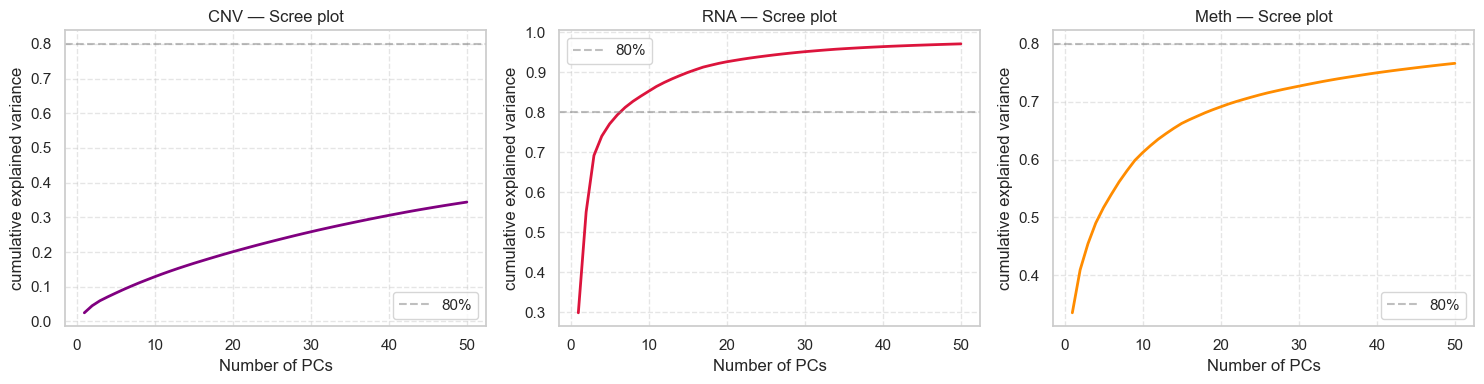

In [24]:
N_COMPONENTS = 50
RANDOM_STATE = 0

def fit_pca(mat: pd.DataFrame, n_components: int, name: str):
    # Safety measures to avoid exceeding the matrix dimensions
    n_comp = min(n_components, mat.shape[0] - 1, mat.shape[1])
    
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(mat.values)
    
    pcs_df = pd.DataFrame(
        pcs,
        index=mat.index,
        columns=[f"PC{i+1}_{name}" for i in range(n_comp)]
    )
    
    var_explained = pca.explained_variance_ratio_.cumsum()[-1]
    print(f"[{name}] {mat.shape[1]:,} features → {n_comp} PCs "
          f"(cumulative explained variance : {var_explained:.1%})")
          
    return pca, pcs_df

pca_cnv,  pcs_cnv  = fit_pca(X_cnv_final,  N_COMPONENTS, "CNV")
pca_rna,  pcs_rna  = fit_pca(X_rna_final,  N_COMPONENTS, "RNA")
pca_meth, pcs_meth = fit_pca(X_meth_final, N_COMPONENTS, "Meth")

#Graohics 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pca, name, color in [
    (axes[0], pca_cnv,  "CNV",  "purple"),
    (axes[1], pca_rna,  "RNA",  "crimson"),
    (axes[2], pca_meth, "Meth", "darkorange"),
]:
    cumvar = pca.explained_variance_ratio_.cumsum()
    ax.plot(range(1, len(cumvar)+1), cumvar, color=color, linewidth=2)
    ax.axhline(0.8, ls="--", color="grey", alpha=0.5, label="80%")
    
    ax.set_xlabel("Number of PCs")
    ax.set_ylabel("cumulative explained variance")
    ax.set_title(f"{name} — Scree plot")
    ax.legend()

plt.tight_layout()
plt.show()

### PCA :
Concatanate firsrt and do the PCA afterward


In [25]:
def find_n_pcs_for_variance(mat, target_variance=0.80, max_pcs=150, name=""):
    n_max = min(max_pcs, mat.shape[0]-1, mat.shape[1])
    pca = PCA(n_components=n_max, random_state=0)
    pca.fit(mat.values)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_pcs = int(np.searchsorted(cumvar, target_variance)) + 1
    print(f"[{name}] → {n_pcs} PCs pour atteindre {target_variance:.0%} de variance "
          f"(sur {mat.shape[1]:,} features)")
    return pca, n_pcs, cumvar

pca_cnv_A,  n_cnv_A,  cumvar_cnv  = find_n_pcs_for_variance(X_cnv_final,  name="CNV")
pca_rna_A,  n_rna_A,  cumvar_rna  = find_n_pcs_for_variance(X_rna_final,  name="RNA")
pca_meth_A, n_meth_A, cumvar_meth = find_n_pcs_for_variance(X_meth_final, name="Meth")


def weight_by_ncols(mat: pd.DataFrame) -> pd.DataFrame:
    """Divise par sqrt(n_features) pour équilibrer la contribution de chaque omique."""
    return mat / np.sqrt(mat.shape[1])

#X_cnv_w  = weight_by_ncols(X_cnv_final)
X_cnv_w  = weight_by_ncols(X_cnv_final)
X_rna_w  = weight_by_ncols(X_rna_final)
X_meth_w = weight_by_ncols(X_meth_final)

# Concaténation
X_concat = pd.concat([X_cnv_w, X_rna_w, X_meth_w], axis=1)
print(f"[CAS B] Matrice concaténée : {X_concat.shape}")

# PCA globale — on cherche le N pour 80% de variance
pca_global_B, n_global_B, cumvar_global = find_n_pcs_for_variance(
    X_concat, target_variance=0.80, max_pcs=200, name="Global"
)

pcs_global_B = pd.DataFrame(
    pca_global_B.transform(X_concat.values)[:, :n_global_B],
    index=X_concat.index,
    columns=[f"PC{i+1}" for i in range(n_global_B)]
)

print(f"\n[CAS B] Dimensions finales : {pcs_global_B.shape}")

[CNV] → 151 PCs pour atteindre 80% de variance (sur 5,128 features)
[RNA] → 7 PCs pour atteindre 80% de variance (sur 1,301 features)
[Meth] → 85 PCs pour atteindre 80% de variance (sur 1,171 features)
[CAS B] Matrice concaténée : (9592, 7600)
[Global] → 19 PCs pour atteindre 80% de variance (sur 7,600 features)

[CAS B] Dimensions finales : (9592, 19)


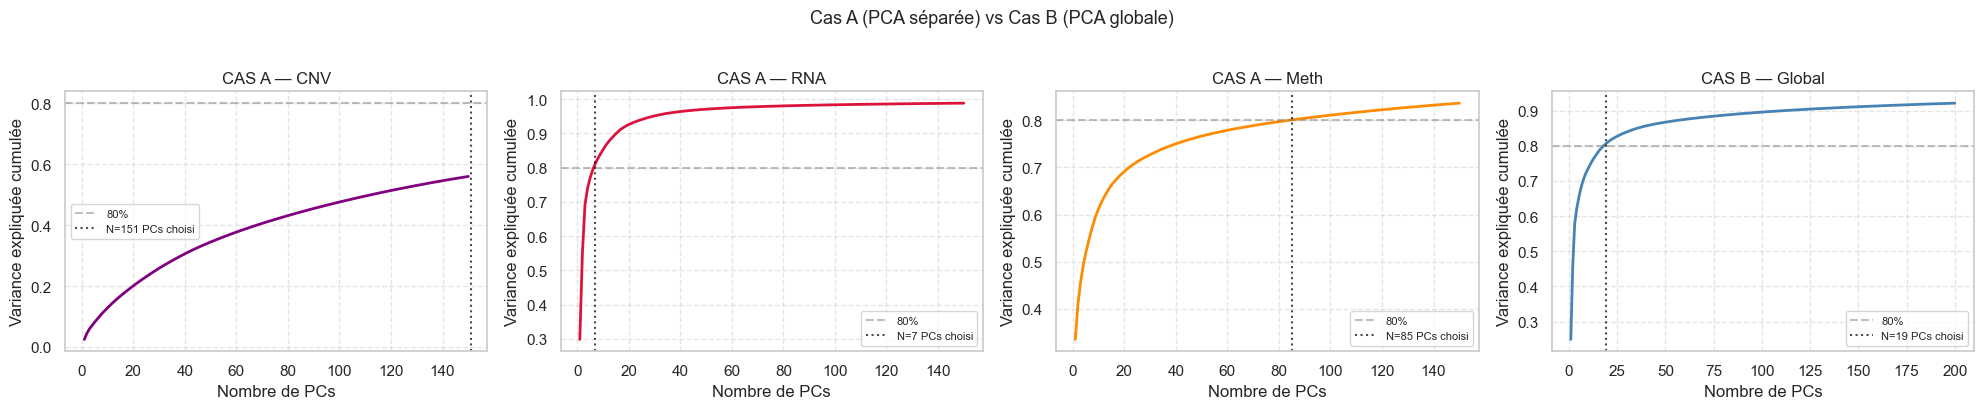


RÉSUMÉ
CAS A — PCA séparée :
  CNV  : 151 PCs
  RNA  : 7 PCs
  Meth : 85 PCs
  Total dimensions pour intégration : 243

CAS B — PCA globale :
  19 PCs (toutes omiques confondues)


In [26]:
# ── Scree plots côte à côte ───────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, cumvar, name, color, n_chosen in [
    (axes[0], cumvar_cnv,    "CAS A — CNV",    "purple",     n_cnv_A),
    (axes[1], cumvar_rna,    "CAS A — RNA",    "crimson",    n_rna_A),
    (axes[2], cumvar_meth,   "CAS A — Meth",   "darkorange", n_meth_A),
    (axes[3], cumvar_global, "CAS B — Global", "steelblue",  n_global_B),
]:
    ax.plot(range(1, len(cumvar)+1), cumvar, color=color, linewidth=2)
    ax.axhline(0.80, ls="--", color="grey", alpha=0.5, label="80%")
    ax.axvline(n_chosen, ls=":", color="black", alpha=0.7,
               label=f"N={n_chosen} PCs choisi")
    ax.set_xlabel("Nombre de PCs")
    ax.set_ylabel("Variance expliquée cumulée")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle("Cas A (PCA séparée) vs Cas B (PCA globale)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Résumé chiffré ────────────────────────────────────────────
print("\n" + "="*50)
print("RÉSUMÉ")
print("="*50)
print(f"CAS A — PCA séparée :")
print(f"  CNV  : {n_cnv_A} PCs")
print(f"  RNA  : {n_rna_A} PCs")
print(f"  Meth : {n_meth_A} PCs")
print(f"  Total dimensions pour intégration : {n_cnv_A + n_rna_A + n_meth_A}")
print(f"\nCAS B — PCA globale :")
print(f"  {n_global_B} PCs (toutes omiques confondues)")

In [27]:
# ============================================================
# Décision finale : 20 PCs équilibrés par omique
# ============================================================
N_FIXED = 20

def apply_pca_fixed(mat, pca_fitted, n_pcs, name):
    n = min(n_pcs, pca_fitted.n_components_)
    pcs = pca_fitted.transform(mat.values)[:, :n]
    pcs_df = pd.DataFrame(
        pcs,
        index=mat.index,
        columns=[f"{name}_PC{i+1}" for i in range(n)]
    )
    var = float(np.cumsum(pca_fitted.explained_variance_ratio_)[n-1])
    print(f"[{name}] {n} PCs → variance expliquée : {var:.1%}")
    return pcs_df

pcs_cnv  = apply_pca_fixed(X_cnv_final, pca_cnv_A, N_FIXED, "CNV")
pcs_rna  = apply_pca_fixed(X_rna_final, pca_rna_A, N_FIXED, "RNA")
pcs_meth = apply_pca_fixed(X_meth_final, pca_meth_A, N_FIXED, "Meth")

[CNV] 20 PCs → variance expliquée : 20.1%
[RNA] 20 PCs → variance expliquée : 92.6%
[Meth] 20 PCs → variance expliquée : 69.1%


### UMAP :
For the PCA we choose to do the PCA on the separated omics.
verify that each omics alone already captures a coherent biological signal

[CNV] UMAP calculated on N_COMPONENTS = 20 9,592 samples x 20 PCs
[RNA] UMAP calculated on N_COMPONENTS = 20 9,592 samples x 20 PCs
[Meth] UMAP calculated on N_COMPONENTS = 20 9,592 samples x 20 PCs


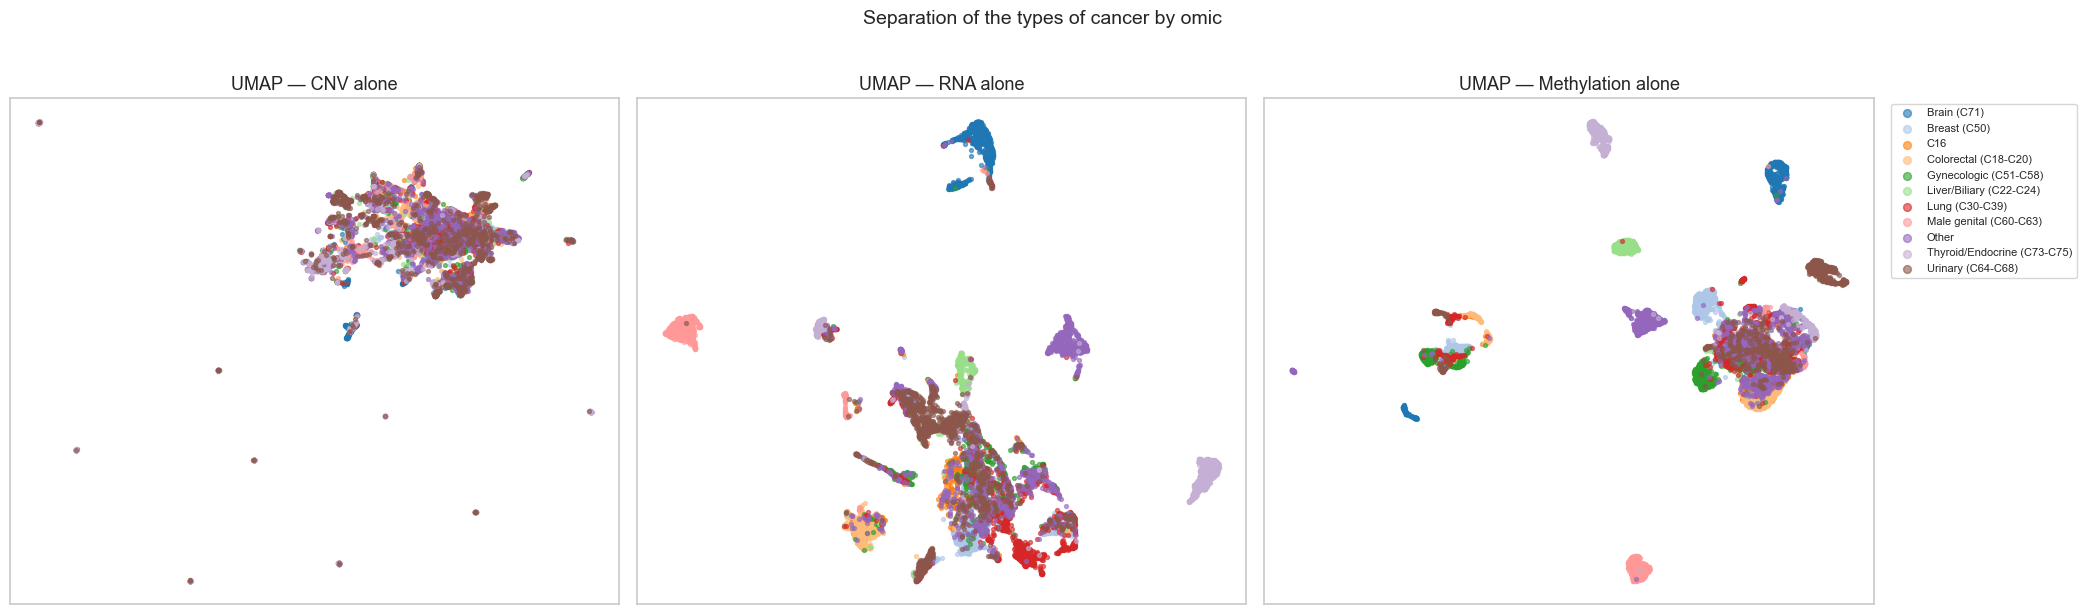

In [28]:
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.1
UMAP_METRIC      = "cosine"

def fit_umap(pcs_df: pd.DataFrame, name: str):
    reducer = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=RANDOM_STATE,
    )
    emb = reducer.fit_transform(pcs_df.values)
    emb_df = pd.DataFrame(emb, index=pcs_df.index, columns=["UMAP1", "UMAP2"])
    print(f"[{name}] UMAP calculated on N_COMPONENTS = 20 {pcs_df.shape[0]:,} samples x {pcs_df.shape[1]} PCs")
    return emb_df

emb_cnv  = fit_umap(pcs_cnv,  "CNV")
emb_rna  = fit_umap(pcs_rna,  "RNA")
emb_meth = fit_umap(pcs_meth, "Meth")

# Colored by topography (cancer type) Top 10 
top_topos = meta_final["cancer_group"].value_counts().head(10).index
meta_plot = meta_final.copy()
meta_plot["topo_label"] = meta_plot["cancer_group"].where(
    meta_plot["cancer_group"].isin(top_topos), other="Other"
)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
palette = sns.color_palette("tab20", n_colors=meta_plot["topo_label"].nunique())

for ax, emb, name in [
    (axes[0], emb_cnv,  "CNV alone"),
    (axes[1], emb_rna,  "RNA alone"),
    (axes[2], emb_meth, "Methylation alone"),
]:
    df_plot = emb.copy()
    df_plot["topo_label"] = meta_plot["topo_label"].values

    for i, (label, grp) in enumerate(df_plot.groupby("topo_label")):
        ax.scatter(grp["UMAP1"], grp["UMAP2"],
                   s=8, alpha=0.6, label=label, color=palette[i])
    ax.set_title(f"UMAP — {name}", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

axes[2].legend(markerscale=2, bbox_to_anchor=(1.02, 1),
               loc="upper left", fontsize=8)
plt.suptitle("Separation of the types of cancer by omic", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Saved 
saved the PCs to use later

In [29]:
out_dir_preproc = Path("/Users/bgadmin/Downloads/multiomics_preproc")
out_dir_preproc.mkdir(parents=True, exist_ok=True)

# PCs by omic
pcs_cnv.to_parquet(out_dir_preproc  / "pcs_cnv.parquet")
pcs_rna.to_parquet(out_dir_preproc  / "pcs_rna.parquet")
pcs_meth.to_parquet(out_dir_preproc / "pcs_meth.parquet")

# Metadata aligned
meta_final.to_csv(out_dir_preproc / "meta_final.tsv", sep="\t", index=False)

# PCA models (useful for projecting cell lines later)
joblib.dump(pca_cnv,  out_dir_preproc / "pca_cnv.joblib")
joblib.dump(pca_rna,  out_dir_preproc / "pca_rna.joblib")
joblib.dump(pca_meth, out_dir_preproc / "pca_meth.joblib")

print("Files saved :")
for f in sorted(out_dir_preproc.iterdir()):
    print(f"  {f.name}")

Files saved :
  clustering_leiden
  clustering_leiden_A
  comparison_axe1_vs_axe2
  inference
  knn_index
  meta_final.tsv
  mofa_factors.parquet
  mofa_model.hdf5
  mofa_r2_per_factor.tsv
  mofa_umap.parquet
  pca_cnv.joblib
  pca_cnv_A.joblib
  pca_meth.joblib
  pca_meth_A.joblib
  pca_rna.joblib
  pca_rna_A.joblib
  pcs_cnv.parquet
  pcs_meth.parquet
  pcs_rna.parquet
  scaler_cnv.joblib
  scaler_meth.joblib
  scaler_rna.joblib
  subtyping
  validation


In [30]:

out_dir_preproc.mkdir(parents=True, exist_ok=True)

# Saving Scalers to guarantee reproducibility and inference
joblib.dump(scaler_cnv,  out_dir_preproc / "scaler_cnv.joblib")
joblib.dump(scaler_rna,  out_dir_preproc / "scaler_rna.joblib")
joblib.dump(scaler_meth, out_dir_preproc / "scaler_meth.joblib")

print(f"3 scalers saved in :  {out_dir_preproc}")

3 scalers saved in :  /Users/bgadmin/Downloads/multiomics_preproc


### Multi-omics Integration 
- MOFA
- SNF

In [31]:
# Create lists of unique features by adding a suffix
#features_cnv  = [f"{feat}_CNV" for feat in X_cnv_final.columns]
features_cnv  = [f"{feat}_CNV"  for feat in X_cnv_final.columns]
features_rna  = [f"{feat}_RNA" for feat in X_rna_final.columns]
features_meth = [f"{feat}_Meth" for feat in X_meth_final.columns]

# Initialization of MOFA
ent = entry_point()

ent.set_data_options(scale_groups=False, scale_views=True)

ent.set_data_matrix(
    data=[
        [X_cnv_final.values],   
        [X_rna_final.values],  
        [X_meth_final.values], 
    ],
    views_names=["CNV", "RNA", "Meth"],
    groups_names=["all_samples"],
    samples_names=[list(X_cnv_final.index)],
    features_names=[
        features_cnv,  
        features_rna,  
        features_meth,  
    ]
)

ent.set_model_options(factors=20)  # 20 latents factor

ent.set_train_options(
    iter=1000,
    convergence_mode="fast",
    seed=42,
    verbose=False
)

ent.build()
ent.run()

# Retrieve the latents factor (samples × factors)
Z_mofa = ent.model.nodes["Z"].getExpectation()
Z_mofa_df = pd.DataFrame(
    Z_mofa, 
    index=X_cnv_final.index,
    columns=[f"Factor{i+1}" for i in range(Z_mofa.shape[1])] 
)

print("Shape of the latent space MOFA :", Z_mofa_df.shape) 


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Scaling views to unit variance...

Successfully loaded view='CNV' group='all_samples' with N=9592 samples and D=5128 features...
Successfully loaded view='RNA' group='all_samples' with N=9592 samples and D=1301 features...
Successfully loaded view='Meth' group='all_samples' with N=9592 samples and D=1171 features...


Model options:
- Automatic Relevance Determination prior on the fact

Variance explained by factor (en %) :
           CNV    RNA   Meth
Factor1   0.41  16.49  16.35
Factor2   0.12   7.94  14.36
Factor3   0.17   2.56  15.45
Factor4  -0.01   1.76   0.89
Factor5   1.98   0.48   1.49
Factor6   1.71   0.15   0.46
Factor7   0.32   3.04   1.68
Factor8   0.88   0.46   2.26
Factor9   0.76   1.12   1.36
Factor10  0.31   0.87   2.90
Factor11  0.56   0.61   0.98
Factor12  0.57   0.55   0.95
Factor13  0.63   0.46   0.78
Factor14  0.76   0.28   0.58
Factor15  0.59   0.21   0.66
Factor16  0.15   0.91   1.62
Factor17  0.64   0.45   0.34
Factor18  0.64   0.74   0.33
Factor19  0.26   1.03   0.76
Factor20  0.48   0.31   0.52


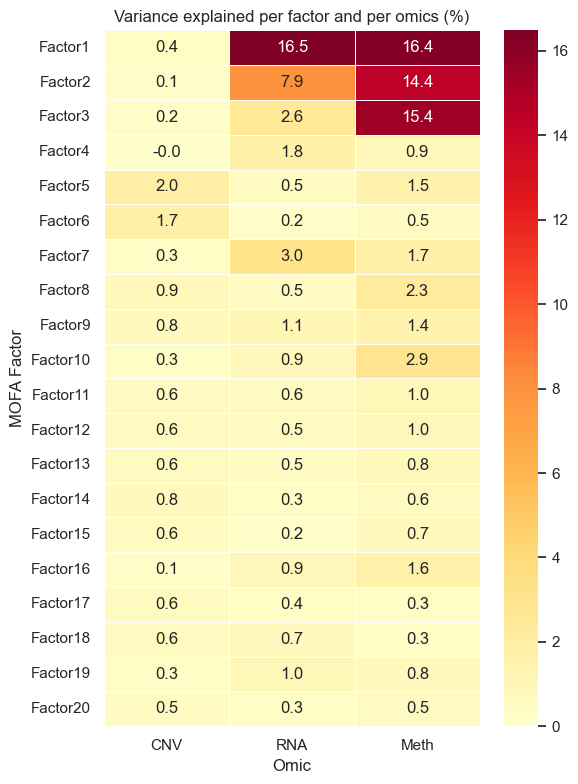

In [32]:
#Analzye of MOFA
#Heatmap
r2_raw = ent.model.calculate_variance_explained()
r2_arr = np.array(r2_raw)  # shape (1, 3, 20)

# r2_arr[0] = (3, 20) → 3 omics × 20 factors
# transposition to have 20 factors × 3 omics
r2_df = pd.DataFrame(
    r2_arr[0].T,  # (20, 3)
    index=[f"Factor{i+1}" for i in range(20)],
    columns=["CNV", "RNA", "Meth"]
)

print("Variance explained by factor (en %) :")
print((r2_df * 100).round(2))

plt.figure(figsize=(6, 8))
sns.heatmap(
    r2_df * 100,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=(r2_df * 100).values.max(),
    linewidths=0.5
)
plt.title("Variance explained per factor and per omics (%)")
plt.xlabel("Omic")
plt.ylabel("MOFA Factor")
plt.tight_layout()
plt.show()

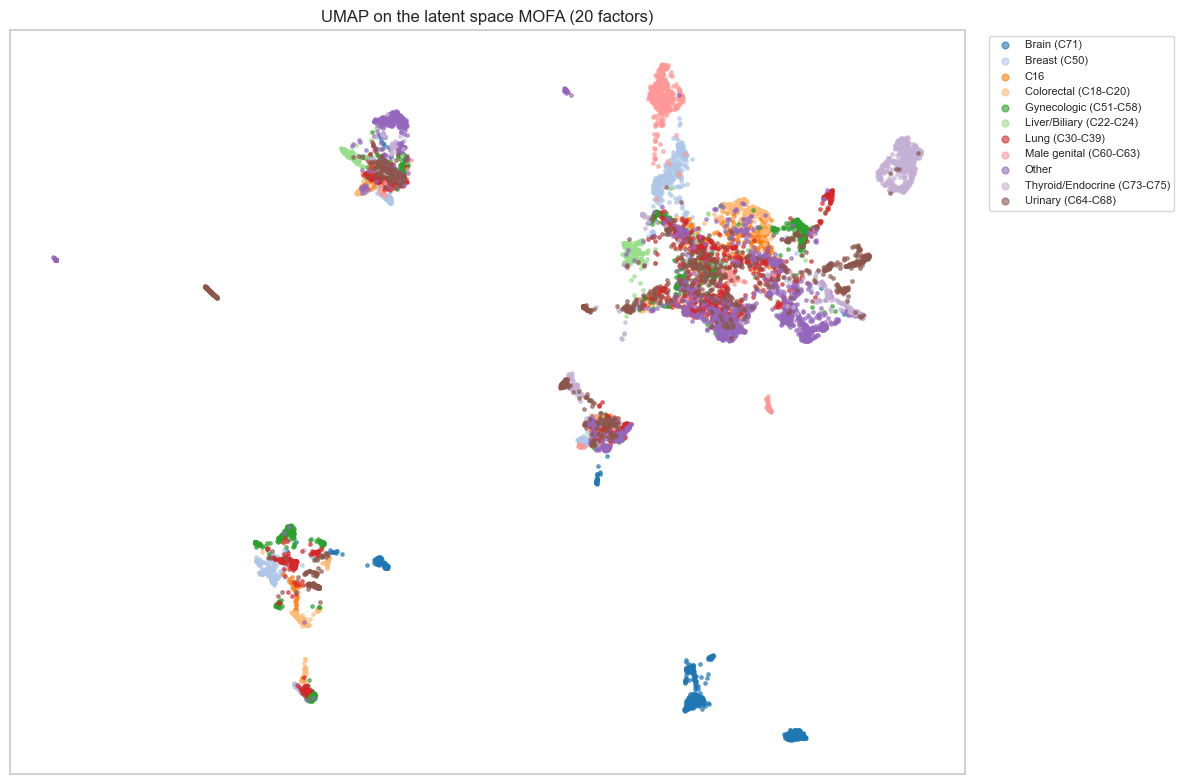

In [33]:
#UMAP MOFA

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, 
                    metric="euclidean", random_state=42)
emb_mofa = reducer.fit_transform(Z_mofa_df.values)

emb_mofa_df = pd.DataFrame(
    emb_mofa,
    index=Z_mofa_df.index,
    columns=["UMAP1", "UMAP2"]
)

# Colored by cancer_group
df_plot = emb_mofa_df.copy()
df_plot["cancer_group"] = meta_final["cancer_group"].values

top_groups = df_plot["cancer_group"].value_counts().head(10).index
df_plot["label"] = df_plot["cancer_group"].where(
    df_plot["cancer_group"].isin(top_groups), other="Other"
)

plt.figure(figsize=(12, 8))
palette = sns.color_palette("tab20", n_colors=df_plot["label"].nunique())
for i, (label, grp) in enumerate(df_plot.groupby("label")):
    plt.scatter(grp["UMAP1"], grp["UMAP2"], 
                s=6, alpha=0.6, label=label, color=palette[i])
plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.title("UMAP on the latent space MOFA (20 factors)")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

In [33]:
# For each factor, does it discriminate against the cancer_group?

y = LabelEncoder().fit_transform(meta_final["cancer_group"])

f_scores, p_values = f_classif(Z_mofa_df.values, y)

factor_disc = pd.DataFrame({
    "factor": Z_mofa_df.columns,
    "f_score": f_scores,
    "p_value": p_values,
    "dominant_omic": r2_df.idxmax(axis=1).values
}).sort_values("f_score", ascending=False)

print(factor_disc.head(10))

      factor     f_score  p_value dominant_omic
0    Factor1  852.811530      0.0           RNA
9   Factor10  492.862385      0.0          Meth
15  Factor16  289.712553      0.0          Meth
11  Factor12  259.670903      0.0          Meth
10  Factor11  257.779459      0.0          Meth
2    Factor3  239.825813      0.0          Meth
6    Factor7  230.409817      0.0           RNA
8    Factor9  186.836947      0.0          Meth
18  Factor19  173.174107      0.0           RNA
3    Factor4  149.681436      0.0           RNA


In [34]:
# SNF
import snf
import sklearn.utils.validation

# MONKEY PATCH to make compatible with the recent version of SCIKIT-LEARN 
_orig_check_array = sklearn.utils.validation.check_array

def _patched_check_array(*args, **kwargs):
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return _orig_check_array(*args, **kwargs)

# The patch is applied directly to the SNF namespace.
snf.compute.check_array = _patched_check_array

from sklearn.cluster import SpectralClustering
import pandas as pd
import umap

# SNF expects raw or normalized matrices (samples × features).
affinity_networks = snf.make_affinity(
    [X_cnv_final.values, X_rna_final.values, X_meth_final.values],
    metric="euclidean",
    K=20,        # number of neighbors to build the network
    mu=0.5       #broadcast parameter
)

# Merged of the 3 networks
fused_network = snf.snf(affinity_networks, K=20)
# fused_network : matrix (n_samples × n_samples) ) of merged similarity

# Find the optimal number of clusters
best_k, second_k = snf.get_n_clusters(fused_network)
print(f"Numer of suggest cluster: {best_k}")

# Spectral clustering on the merged network
labels_snf = SpectralClustering(
    n_clusters=best_k,
    affinity="precomputed",
    random_state=42
).fit_predict(fused_network)

meta_final["cluster_snf"] = labels_snf

# to have a viewable embedding (UMAP on the merged network)
reducer = umap.UMAP(metric="precomputed", random_state=42)
emb_snf = reducer.fit_transform(1 - fused_network)  # distance = 1 - similarité
emb_snf_df = pd.DataFrame(
    emb_snf,
    index=X_cnv_final.index,
    columns=["UMAP1", "UMAP2"]
)

print("SNF exécuté et clustering terminé avec succès !")

KeyboardInterrupt: 

In [35]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans, SpectralClustering
import numpy as np
import pandas as pd

y_true = LabelEncoder().fit_transform(meta_final["cancer_group"])
n_groups = meta_final["cancer_group"].nunique()  # 28 — K fixe pour tout le monde

# CNV alone (PCA)
km_cnv = KMeans(n_clusters=n_groups, random_state=42, n_init=10)
labels_cnv = km_cnv.fit_predict(pcs_cnv.values)
nmi_cnv = normalized_mutual_info_score(y_true, labels_cnv)
ari_cnv = adjusted_rand_score(y_true, labels_cnv)
sil_cnv = silhouette_score(pcs_cnv.values, labels_cnv, sample_size=2000)

# PCA separated by omic 
X_pca_concat = pd.concat([pcs_cnv, pcs_rna, pcs_meth], axis=1)
km_pca_sep = KMeans(n_clusters=n_groups, random_state=42, n_init=10)
labels_pca_sep = km_pca_sep.fit_predict(X_pca_concat.values)
nmi_pca_sep = normalized_mutual_info_score(y_true, labels_pca_sep)
ari_pca_sep = adjusted_rand_score(y_true, labels_pca_sep)
sil_pca_sep = silhouette_score(X_pca_concat.values, labels_pca_sep, sample_size=2000)

# MOFA
km_mofa = KMeans(n_clusters=n_groups, random_state=42, n_init=10)
labels_mofa = km_mofa.fit_predict(Z_mofa_df.values)
nmi_mofa = normalized_mutual_info_score(y_true, labels_mofa)
ari_mofa = adjusted_rand_score(y_true, labels_mofa)
sil_mofa = silhouette_score(Z_mofa_df.values, labels_mofa, sample_size=2000)

# SNF 
labels_snf_28 = SpectralClustering(
    n_clusters=n_groups,
    affinity="precomputed",
    random_state=42
).fit_predict(fused_network)
nmi_snf = normalized_mutual_info_score(y_true, labels_snf_28)
ari_snf = adjusted_rand_score(y_true, labels_snf_28)
dist_snf = 1 - fused_network
np.fill_diagonal(dist_snf, 0)
sil_snf = silhouette_score(dist_snf, labels_snf_28, metric="precomputed", sample_size=2000)

# Final comparative table
comparison_df = pd.DataFrame({
    "Méthode":    ["CNV alone (PCA)", "separated PCA", "MOFA", "SNF"],
    "NMI":        [nmi_cnv, nmi_pca_sep, nmi_mofa, nmi_snf],
    "ARI":        [ari_cnv, ari_pca_sep, ari_mofa, ari_snf],
    "Silhouette": [sil_cnv, sil_pca_sep, sil_mofa, sil_snf],
})

print("Comparative clustering performances (K=28 partout) :")
print(comparison_df.round(3).to_string(index=False))

NameError: name 'fused_network' is not defined

NameError: name 'fused_network' is not defined

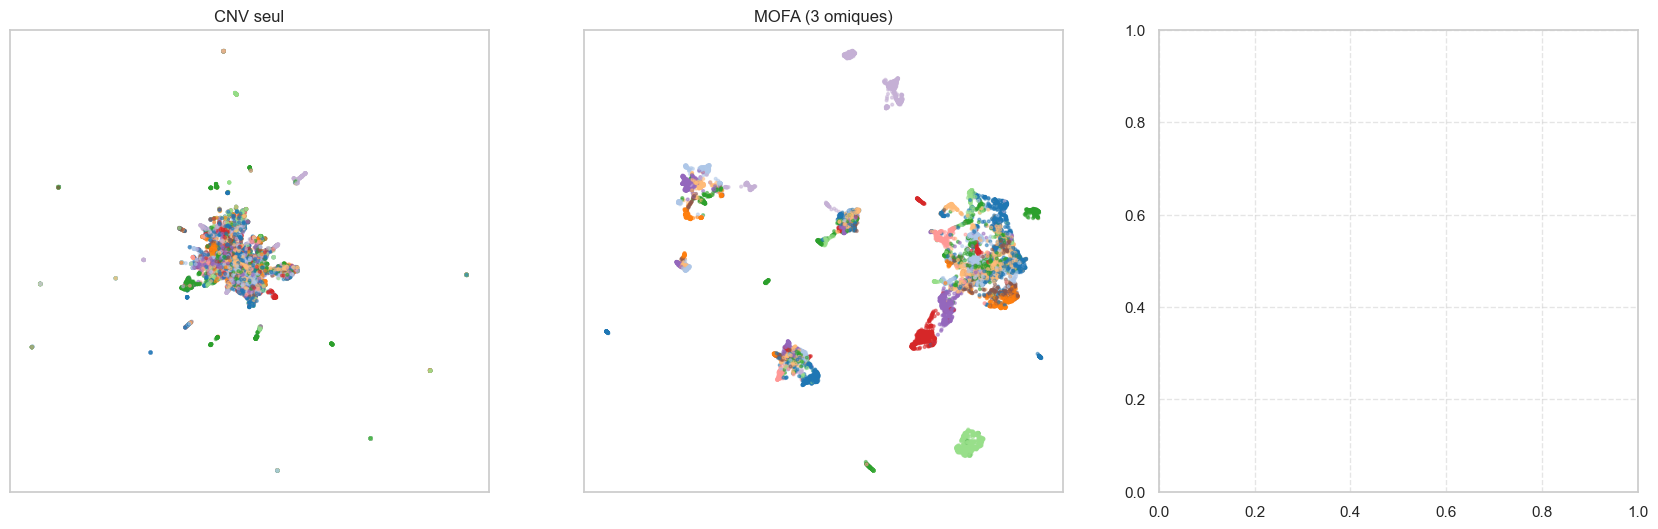

In [34]:
# Visualisation UMAP côte à côte pour comparer visuellement
import umap
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Labels pour colorier
top_groups = meta_final["cancer_group"].value_counts().head(10).index
color_label = meta_final["cancer_group"].where(
    meta_final["cancer_group"].isin(top_groups), other="Other"
)
palette = sns.color_palette("tab20", n_colors=color_label.nunique())
color_map = {g: palette[i] for i, g in enumerate(color_label.unique())}
colors = [color_map[g] for g in color_label]

# UMAP CNV seul
reducer = umap.UMAP(random_state=42)
emb_cnv = reducer.fit_transform(pcs_cnv.values)
axes[0].scatter(emb_cnv[:,0], emb_cnv[:,1], c=colors, s=4, alpha=0.5)
axes[0].set_title("CNV seul")
axes[0].set_xticks([]); axes[0].set_yticks([])

# UMAP MOFA
emb_mofa = reducer.fit_transform(Z_mofa_df.values)
axes[1].scatter(emb_mofa[:,0], emb_mofa[:,1], c=colors, s=4, alpha=0.5)
axes[1].set_title("MOFA (3 omiques)")
axes[1].set_xticks([]); axes[1].set_yticks([])

# UMAP SNF (distance precomputed)
reducer_snf = umap.UMAP(metric="precomputed", random_state=42)
emb_snf_umap = reducer_snf.fit_transform(1 - fused_network)
axes[2].scatter(emb_snf_umap[:,0], emb_snf_umap[:,1], c=colors, s=4, alpha=0.5)
axes[2].set_title("SNF (3 omiques)")
axes[2].set_xticks([]); axes[2].set_yticks([])

# Légende sur le dernier axe
handles = [plt.scatter([], [], c=[color_map[g]], s=20, label=g) 
           for g in color_map]
axes[2].legend(handles=handles, bbox_to_anchor=(1.02, 1), 
               loc="upper left", fontsize=7, markerscale=2)
plt.suptitle("Comparaison des espaces d'intégration", fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# PCs par omique (20 PCs chacun)
pcs_cnv.to_parquet(out_dir_preproc / "pcs_cnv.parquet")
pcs_rna.to_parquet(out_dir_preproc / "pcs_rna.parquet")
pcs_meth.to_parquet(out_dir_preproc / "pcs_meth.parquet")

# Métadonnées
meta_final.to_csv(out_dir_preproc / "meta_final.tsv", sep="\t", index=False)

# Modèles PCA
joblib.dump(pca_cnv_A,  out_dir_preproc / "pca_cnv_A.joblib")
joblib.dump(pca_rna_A,  out_dir_preproc / "pca_rna_A.joblib")
joblib.dump(pca_meth_A, out_dir_preproc / "pca_meth_A.joblib")

# Scalers
joblib.dump(scaler_cnv,  out_dir_preproc / "scaler_cnv.joblib")
joblib.dump(scaler_rna,  out_dir_preproc / "scaler_rna.joblib")
joblib.dump(scaler_meth, out_dir_preproc / "scaler_meth.joblib")

# MOFA
Z_mofa_df.to_parquet(out_dir_preproc / "mofa_factors.parquet")
emb_mofa_df.to_parquet(out_dir_preproc / "mofa_umap.parquet")
r2_df.to_csv(out_dir_preproc / "mofa_r2_per_factor.tsv", sep="\t")
ent.save(str(out_dir_preproc / "mofa_model.hdf5"))

print("Tout sauvegardé.")
for f in sorted(out_dir_preproc.iterdir()):
    print(f"  {f.name}")

Saving model in /Users/bgadmin/Downloads/multiomics_preproc/mofa_model.hdf5...
Tout sauvegardé.
  clustering_leiden
  clustering_leiden_A
  comparison_axe1_vs_axe2
  inference
  knn_index
  meta_final.tsv
  mofa_factors.parquet
  mofa_model.hdf5
  mofa_r2_per_factor.tsv
  mofa_umap.parquet
  pca_cnv.joblib
  pca_cnv_A.joblib
  pca_meth.joblib
  pca_meth_A.joblib
  pca_rna.joblib
  pca_rna_A.joblib
  pcs_cnv.parquet
  pcs_meth.parquet
  pcs_rna.parquet
  scaler_cnv.joblib
  scaler_meth.joblib
  scaler_rna.joblib
  subtyping
  validation


In [36]:
'''# PCs par omique (20 PCs chacun)
pcs_cnv.to_parquet(out_dir_preproc  / "pcs_cnv.parquet")
pcs_rna.to_parquet(out_dir_preproc  / "pcs_rna.parquet")
pcs_meth.to_parquet(out_dir_preproc / "pcs_meth.parquet")

# PCs CNV globaux complets (50 PCs)
X_cnv_pcs.to_parquet(out_dir_preproc / "cnv_pcs_global.parquet")

# Métadonnées
meta_final.to_csv(out_dir_preproc / "meta_final.tsv", sep="\t", index=False)

# Modèles PCA
joblib.dump(pca_cnv_global, out_dir_preproc / "pca_cnv_global.joblib")
joblib.dump(pca_rna_A,      out_dir_preproc / "pca_rna_A.joblib")
joblib.dump(pca_meth_A,     out_dir_preproc / "pca_meth_A.joblib")

# Scalers
# IMPORTANT : pipeline CNV inférence = PCs locaux → scaler_cnv → pca_cnv_global
joblib.dump(scaler_cnv,  out_dir_preproc / "scaler_cnv_global.joblib")
joblib.dump(scaler_rna,  out_dir_preproc / "scaler_rna.joblib")
joblib.dump(scaler_meth, out_dir_preproc / "scaler_meth.joblib")

# MOFA
Z_mofa_df.to_parquet(out_dir_preproc / "mofa_factors.parquet")
emb_mofa_df.to_parquet(out_dir_preproc / "mofa_umap.parquet")
r2_df.to_csv(out_dir_preproc / "mofa_r2_per_factor.tsv", sep="\t")
ent.save(str(out_dir_preproc / "mofa_model.hdf5"))

print("Tout sauvegardé.")
for f in sorted(out_dir_preproc.iterdir()):
    print(f"  {f.name}")'''

'# PCs par omique (20 PCs chacun)\npcs_cnv.to_parquet(out_dir_preproc  / "pcs_cnv.parquet")\npcs_rna.to_parquet(out_dir_preproc  / "pcs_rna.parquet")\npcs_meth.to_parquet(out_dir_preproc / "pcs_meth.parquet")\n\n# PCs CNV globaux complets (50 PCs)\nX_cnv_pcs.to_parquet(out_dir_preproc / "cnv_pcs_global.parquet")\n\n# Métadonnées\nmeta_final.to_csv(out_dir_preproc / "meta_final.tsv", sep="\t", index=False)\n\n# Modèles PCA\njoblib.dump(pca_cnv_global, out_dir_preproc / "pca_cnv_global.joblib")\njoblib.dump(pca_rna_A,      out_dir_preproc / "pca_rna_A.joblib")\njoblib.dump(pca_meth_A,     out_dir_preproc / "pca_meth_A.joblib")\n\n# Scalers\n# IMPORTANT : pipeline CNV inférence = PCs locaux → scaler_cnv → pca_cnv_global\njoblib.dump(scaler_cnv,  out_dir_preproc / "scaler_cnv_global.joblib")\njoblib.dump(scaler_rna,  out_dir_preproc / "scaler_rna.joblib")\njoblib.dump(scaler_meth, out_dir_preproc / "scaler_meth.joblib")\n\n# MOFA\nZ_mofa_df.to_parquet(out_dir_preproc / "mofa_factors.parque

In [37]:
print([c for c in meta_final.columns if "morpho" in c.lower()])
print(meta_final["icdo_morphology_id"].value_counts().head(10))

['icdo_morphology_id', 'icdo_morphology_label']
icdo_morphology_id
pgx:icdom-81403    1333
pgx:icdom-80703    1106
pgx:icdom-85003     850
pgx:icdom-82603     651
pgx:icdom-87203     418
pgx:icdom-83803     384
pgx:icdom-84413     379
pgx:icdom-83103     358
pgx:icdom-81703     345
pgx:icdom-81203     331
Name: count, dtype: int64


In [ ]:
'''# Sur le golden set original (avant tout filtrage)
gold = pd.read_parquet("gold_standard_20260602_1455.parquet")

cols_cnv = [c for c in gold.columns if c.startswith("cnv_")]
cnv_vals = gold[cols_cnv].values

print(f"Colonnes CNV : {len(cols_cnv)}")
print(f"% valeurs == 0   : {(cnv_vals == 0).mean()*100:.2f}%")
print(f"% valeurs > 0    : {(cnv_vals > 0).mean()*100:.4f}%")
print(f"% valeurs NaN    : {np.isnan(cnv_vals).mean()*100:.2f}%")
print(f"Min / Max        : {np.nanmin(cnv_vals):.4f} / {np.nanmax(cnv_vals):.4f}")

# Combien de samples ont au moins une valeur > 0 ?
has_signal = (gold[cols_cnv] > 0).any(axis=1)
print(f"\nSamples avec au moins 1 CNV > 0 : {has_signal.sum():,} / {len(gold):,}")
print(f"Samples entièrement à 0          : {(~has_signal).sum():,}")

# Vérifier un sample spécifique qui devrait avoir des altérations
print(f"\nTop 5 samples par somme CNV :")
print(gold[cols_cnv].sum(axis=1).sort_values(ascending=False).head())'''

'# Sur le golden set original (avant tout filtrage)\ngold = pd.read_parquet("gold_standard_20260602_1455.parquet")\n\ncols_cnv = [c for c in gold.columns if c.startswith("cnv_")]\ncnv_vals = gold[cols_cnv].values\n\nprint(f"Colonnes CNV : {len(cols_cnv)}")\nprint(f"% valeurs == 0   : {(cnv_vals == 0).mean()*100:.2f}%")\nprint(f"% valeurs > 0    : {(cnv_vals > 0).mean()*100:.4f}%")\nprint(f"% valeurs NaN    : {np.isnan(cnv_vals).mean()*100:.2f}%")\nprint(f"Min / Max        : {np.nanmin(cnv_vals):.4f} / {np.nanmax(cnv_vals):.4f}")\n\n# Combien de samples ont au moins une valeur > 0 ?\nhas_signal = (gold[cols_cnv] > 0).any(axis=1)\nprint(f"\nSamples avec au moins 1 CNV > 0 : {has_signal.sum():,} / {len(gold):,}")\nprint(f"Samples entièrement à 0          : {(~has_signal).sum():,}")\n\n# Vérifier un sample spécifique qui devrait avoir des altérations\nprint(f"\nTop 5 samples par somme CNV :")\nprint(gold[cols_cnv].sum(axis=1).sort_values(ascending=False).head())'

In [ ]:
import pandas as pd
from pathlib import Path

bridge = pd.read_csv("cnv_id_bridge.csv", dtype=str)
gene_panel = pd.read_csv(
    "/Users/bgadmin/Downloads/gene_cnv_cancer_panel.tsv",
    sep="\t",
    usecols=["analysis_id"],
    dtype=str
)

panel_ids = set(gene_panel["analysis_id"].astype(str))
bridge_ids = set(bridge["analysis_id"].astype(str))

print(f"analysis_id dans gene panel  : {len(panel_ids):,}")
print(f"analysis_id dans bridge      : {len(bridge_ids):,}")
print(f"Intersection                 : {len(panel_ids & bridge_ids):,}")
print(f"Panel sans bridge (non traduits) : {len(panel_ids - bridge_ids):,}")

# Vérifier aussi les biosample_id du golden set
golden_meta = pd.read_parquet("gold_standard_20260602_1455.parquet",
                               columns=["biosample_id"])
golden_ids = set(golden_meta["biosample_id"].astype(str))
bridge_bio_ids = set(bridge["biosample_id"].astype(str))

print(f"\nbiosample_id dans golden set : {len(golden_ids):,}")
print(f"biosample_id dans bridge     : {len(bridge_bio_ids):,}")
print(f"Golden couverts par bridge   : {len(golden_ids & bridge_bio_ids):,}")
print(f"Golden sans bridge           : {len(golden_ids - bridge_bio_ids):,}")

analysis_id dans gene panel  : 239,276
analysis_id dans bridge      : 257,365
Intersection                 : 239,276
Panel sans bridge (non traduits) : 0

biosample_id dans golden set : 9,592
biosample_id dans bridge     : 236,403
Golden couverts par bridge   : 9,592
Golden sans bridge           : 0


In [ ]:
import pandas as pd
import numpy as np

bridge = pd.read_csv("cnv_id_bridge.csv", dtype=str)
ana_to_bio = dict(zip(
    bridge["analysis_id"].str.strip(),
    bridge["biosample_id"].str.strip()
))

# Charger TOUT le gene panel — juste analysis_id
print("Chargement du gene panel complet...")
panel_ids = pd.read_csv(
    "/Users/bgadmin/Downloads/gene_cnv_cancer_panel.tsv",
    sep="\t",
    usecols=["analysis_id"],
    dtype=str
)["analysis_id"].unique()
print(f"analysis_id uniques dans gene panel : {len(panel_ids):,}")

# Traduire tous les analysis_id en biosample_id
bio_ids_from_panel = set()
for ana in panel_ids:
    bio = ana_to_bio.get(str(ana).strip(), "")
    if bio:
        bio_ids_from_panel.add(bio)

print(f"biosample_id uniques dans gene panel (via bridge) : {len(bio_ids_from_panel):,}")

# Comparer avec le golden set
gold = pd.read_parquet("gold_standard_20260602_1455.parquet",
                       columns=["biosample_id"])
golden_ids = set(gold["biosample_id"].astype(str))

overlap = golden_ids & bio_ids_from_panel
print(f"\nGolden set couverts par gene panel : {len(overlap):,} / {len(golden_ids):,}")
print(f"Golden set NON couverts            : {len(golden_ids - bio_ids_from_panel):,}")

# Si couverture partielle — regarder quelques non-couverts
if len(golden_ids - bio_ids_from_panel) > 0:
    missing = list(golden_ids - bio_ids_from_panel)[:5]
    print(f"\nExemples de biosample_id du golden set absents du gene panel :")
    for b in missing:
        print(f"  {b}")
    
    # Ces biosample_id sont-ils dans le bridge ?
    bridge_bio = set(bridge["biosample_id"].str.strip())
    print(f"\nCes biosample_id sont dans le bridge : "
          f"{len(set(missing) & bridge_bio)}/{len(missing)}")

Chargement du gene panel complet...
analysis_id uniques dans gene panel : 239,276
biosample_id uniques dans gene panel (via bridge) : 218,351

Golden set couverts par gene panel : 9,592 / 9,592
Golden set NON couverts            : 0


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

gold = pd.read_parquet("gold_standard_20260604_1206.parquet")

print("=== STRUCTURE ===")
print(f"Shape : {gold.shape}")
print(f"biosample_id uniques : {gold['biosample_id'].nunique():,}")

# Colonnes par omique
cnv_cols  = [c for c in gold.columns if c.startswith("cnv_")]
rna_cols  = [c for c in gold.columns if c.startswith("rna_")]
meth_cols = [c for c in gold.columns if c.startswith("meth_")]
meta_cols = [c for c in gold.columns if not any(
    c.startswith(p) for p in ["cnv_", "rna_", "meth_"])]

print(f"\nColonnes CNV  : {len(cnv_cols)}")
print(f"Colonnes RNA  : {len(rna_cols)}")
print(f"Colonnes Meth : {len(meth_cols)}")
print(f"Colonnes meta : {len(meta_cols)}")

# ── CNV ───────────────────────────────────────────────────────
print("\n=== CNV ===")
dup_cols = [c for c in cnv_cols if c.endswith("__dup")]
del_cols = [c for c in cnv_cols if c.endswith("__del")]

vals_dup = gold[dup_cols].values.flatten()
vals_del = gold[del_cols].values.flatten()

print(f"% dup > 0    : {(vals_dup > 0).mean()*100:.2f}%")
print(f"% dup > 0.1  : {(vals_dup > 0.1).mean()*100:.2f}%")
print(f"% del > 0    : {(vals_del > 0).mean()*100:.2f}%")
print(f"mean non-zero dup : {vals_dup[vals_dup > 0].mean():.4f}")
print(f"Samples avec CNV  : {(gold[dup_cols] > 0).any(axis=1).sum():,}")
print(f"Samples sans CNV  : {(gold[dup_cols] == 0).all(axis=1).sum():,}")

# Gènes cancer clés
for gene in ["TP53", "MYC", "CDKN2A", "EGFR", "PTEN", "RB1"]:
    col = f"cnv_{gene}__dup"
    if col in gold.columns:
        n = (gold[col] > 0).sum()
        print(f"  {gene}__dup > 0 : {n:,} samples ({n/len(gold)*100:.1f}%)")

# ── RNA ───────────────────────────────────────────────────────
print("\n=== RNA ===")
vals_rna = gold[rna_cols].values.flatten()
print(f"% NaN        : {np.isnan(vals_rna).mean()*100:.1f}%")
print(f"% == 0       : {(vals_rna == 0).mean()*100:.1f}%")
print(f"min / max    : {np.nanmin(vals_rna):.2f} / {np.nanmax(vals_rna):.2f}")
print(f"Samples avec RNA : {gold[rna_cols].notna().any(axis=1).sum():,}")

# ── Meth ──────────────────────────────────────────────────────
print("\n=== Methylation ===")
vals_meth = gold[meth_cols].values.flatten()
print(f"% NaN        : {np.isnan(vals_meth).mean()*100:.1f}%")
print(f"% dans [0,1] : {((vals_meth >= 0) & (vals_meth <= 1)).mean()*100:.1f}%")
print(f"min / max    : {np.nanmin(vals_meth):.4f} / {np.nanmax(vals_meth):.4f}")
print(f"Samples avec Meth : {gold[meth_cols].notna().any(axis=1).sum():,}")

# ── Les 3 omiques simultanément ───────────────────────────────
print("\n=== Couverture simultanée ===")
has_cnv  = (gold[dup_cols] > 0).any(axis=1)
has_rna  = gold[rna_cols].notna().any(axis=1)
has_meth = gold[meth_cols].notna().any(axis=1)

print(f"CNV seul          : {has_cnv.sum():,}")
print(f"RNA seul          : {has_rna.sum():,}")
print(f"Meth seule        : {has_meth.sum():,}")
print(f"CNV + RNA         : {(has_cnv & has_rna).sum():,}")
print(f"CNV + Meth        : {(has_cnv & has_meth).sum():,}")
print(f"RNA + Meth        : {(has_rna & has_meth).sum():,}")
print(f"CNV + RNA + Meth  : {(has_cnv & has_rna & has_meth).sum():,}")

# ── Métadonnées ───────────────────────────────────────────────
print("\n=== Métadonnées ===")
if "icdo_topography_id" in gold.columns:
    print(f"icdo_topography_id non-nul : {gold['icdo_topography_id'].notna().sum():,}")
if "icdo_morphology_id" in gold.columns:
    print(f"icdo_morphology_id non-nul : {gold['icdo_morphology_id'].notna().sum():,}")
if "cohorts" in gold.columns:
    print(f"\nTop 5 cohorts :")
    print(gold["cohorts"].value_counts().head(5))

=== STRUCTURE ===
Shape : (9592, 10183)
biosample_id uniques : 9,592

Colonnes CNV  : 5204
Colonnes RNA  : 2601
Colonnes Meth : 2332
Colonnes meta : 46

=== CNV ===
% dup > 0    : 13.41%
% dup > 0.1  : 13.36%
% del > 0    : 13.69%
mean non-zero dup : 0.4982
Samples avec CNV  : 8,340
Samples sans CNV  : 1,252
  TP53__dup > 0 : 503 samples (5.2%)
  MYC__dup > 0 : 4,003 samples (41.7%)
  CDKN2A__dup > 0 : 669 samples (7.0%)
  EGFR__dup > 0 : 2,974 samples (31.0%)
  PTEN__dup > 0 : 508 samples (5.3%)
  RB1__dup > 0 : 948 samples (9.9%)

=== RNA ===
% NaN        : 50.0%
% == 0       : 1.7%
min / max    : -1.25 / 173270.06
Samples avec RNA : 9,592

=== Methylation ===
% NaN        : 50.4%
% dans [0,1] : 49.5%
min / max    : -4.2175 / 6.6680
Samples avec Meth : 9,592

=== Couverture simultanée ===
CNV seul          : 8,340
RNA seul          : 9,592
Meth seule        : 9,592
CNV + RNA         : 8,340
CNV + Meth        : 8,340
RNA + Meth        : 9,592
CNV + RNA + Meth  : 8,340

=== Métadonnées

In [45]:
print(f"CNV matrix shape: {X_cnv_final.shape}")

print(f"CNV columns: {X_cnv_clean.columns.tolist()[:10]}")  # affiche les 10 premières colonnes pour voir le format

CNV matrix shape: (9592, 5128)
CNV columns: ['A1CF__dup', 'ABCB1__dup', 'ABCC3__dup', 'ABI1__dup', 'ABL1__dup', 'ABL2__dup', 'ABRAXAS1__dup', 'ACKR3__dup', 'ACSL3__dup', 'ACSL6__dup']
